#I. Data set description

| Variable | Type | Description | Units |
|:---------|:-----|:------------|:------|
| `id_lab` | Character | Laboratory sample identifier | — |
| `id` | Character | Germplasm accession identifier | — |
| `subset` | Integer | Experimental subset identifier | — |
| `no` | Numeric | Sample number | — |
| `requisitioner` | Character | Source or requesting program of the accession | — |
| `tax_name` | Character | Scientific (taxonomic) name of the species | — |
| `functional_group` | Character | Functional group classification | — |
| `n_replicates_nutrition` | Integer | Number of replicates used for nutritional analyses | Replicates |
| `dm_percentage` | Numeric | Dry matter (DM) content | % |
| `ash_dm` | Numeric | Ash content on a dry matter basis | % DM |
| `om_percentage` | Numeric | Organic matter content | % |
| `pc_percentage_dm` | Numeric | Crude protein (CP) content on a dry matter basis | % DM |
| `adf_percentage_dm` | Numeric | Acid detergent fiber (ADF) content on a dry matter basis | % DM |
| `ndf_percentage_dm` | Numeric | Neutral detergent fiber (NDF) content on a dry matter basis | % DM |
| `n_replicates_gas` | Integer | Number of replicates used for gas production measurements | Replicates |
| `ch4_percentage_in_gas_8h` | Numeric | Methane concentration in fermentation gas after 8 h of incubation | % |
| `ch4_percentage_in_gas_24h` | Numeric | Methane concentration in fermentation gas after 24 h of incubation | % |
| `methane_intensity` | Numeric | Methane intensity measured during fermentation | *(units depend on calculation protocol)* |
| `tddm` | Numeric | True dry matter digestibility (TDDM) | % |

# 1.0 Install packages and import libraries

In [ ]:
install.packages(c("patchwork", "viridis", "car", "dplyr", "lme4", "emmeans", "lmerTest"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘rbibutils’, ‘gridExtra’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’




In [ ]:
library(dplyr)
library(lme4)
library(ggplot2)
library(patchwork)
library(viridis)
library(car)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loading required package: viridisLite

Loading required package: carData

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




# 2.0 Data load

In [ ]:
url_compiled <- "https://raw.githubusercontent.com/maurope/lmf/main/output/2026_05_22_data_delivery/08_dashboard_june_2026/compiled_dashboard_2026_7_10.csv"
compiled <- read.csv(url_compiled)

url_gas_raw <- "https://raw.githubusercontent.com/maurope/lmf/main/output/2026_06_09_trial_database_curation/gas_clean_complete_subsets_1234_2026_06_09.csv"
gas_raw <- read.csv(url_gas_raw)

In [ ]:
#Remove unofficial functional groups
compiled <- compiled %>%
  filter(!functional_group %in% c("Concentrate", "Forage", ""))

In [ ]:
head(compiled)

,id_lab,id,subset,no,requisitioner,tax_name,functional_group,n_replicates_nutrition,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm,n_replicates_gas,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,F24-3470,CIAT-11194,1,199,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,92.89,9.61,90.39,21.18,30.18,55.94,6,15.17,18.02,46.12,59.25
2,F24-3471,CIAT-11999,1,201,Genetic_bank,Stylosanthes guianensis,Herbaceous_legumes,2,93.50,10.46,89.54,20.09,33.90,61.32,9,12.98,16.25,46.61,58.55
3,F24-3472,CIAT-12318,1,203,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,94.10,11.08,88.92,22.05,29.34,55.26,9,13.99,16.96,52.27,56.88
4,F24-3427,CIAT-1257,1,113,Genetic_bank,Stylosanthes scabra,Herbaceous_legumes,2,92.72,9.52,90.48,17.96,35.90,69.91,9,15.71,17.60,46.32,58.95
5,F24-3473,CIAT-13575,1,205,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,94.14,11.52,88.48,23.17,44.09,57.61,9,13.60,16.23,42.43,42.85
6,F24-3474,CIAT-13609,1,207,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,93.40,11.58,88.42,20.01,40.85,58.78,9,13.66,16.31,46.39,38.40


# 3.0 Descriptive stats

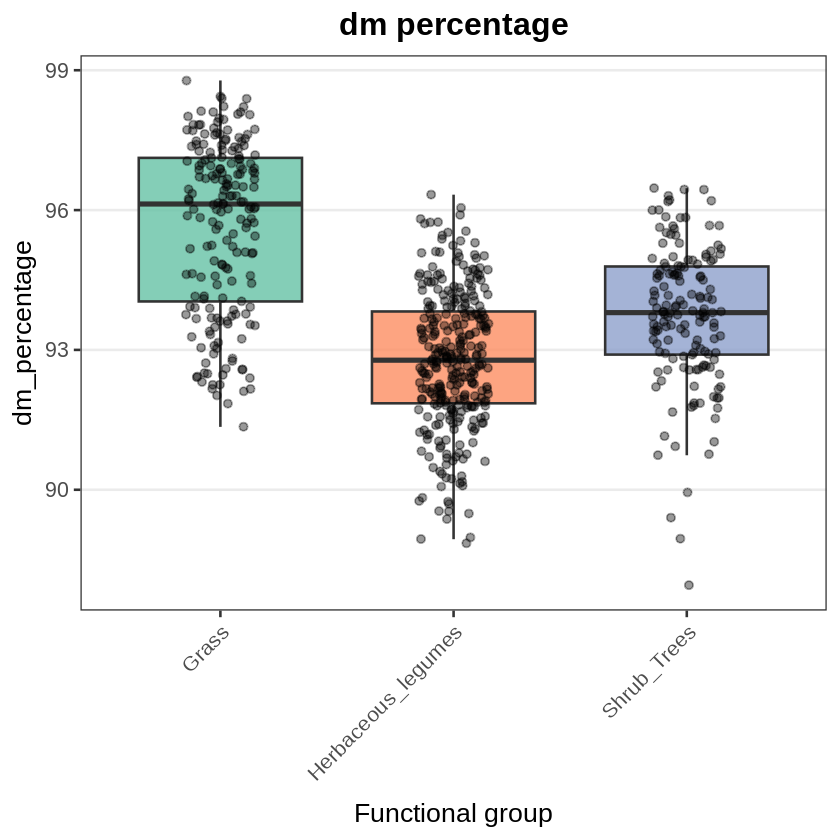

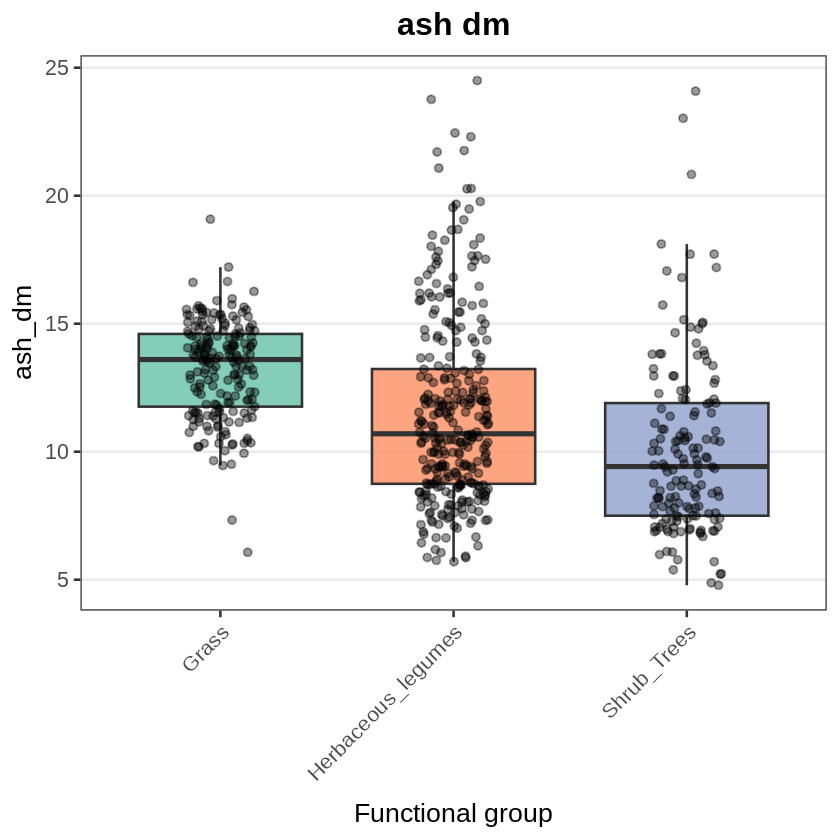

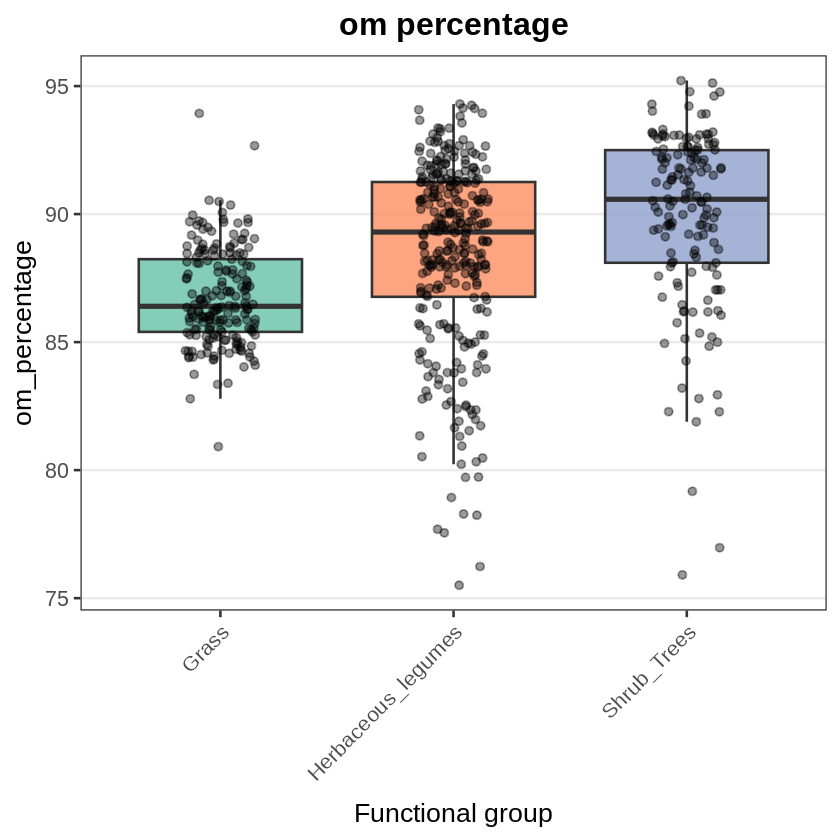

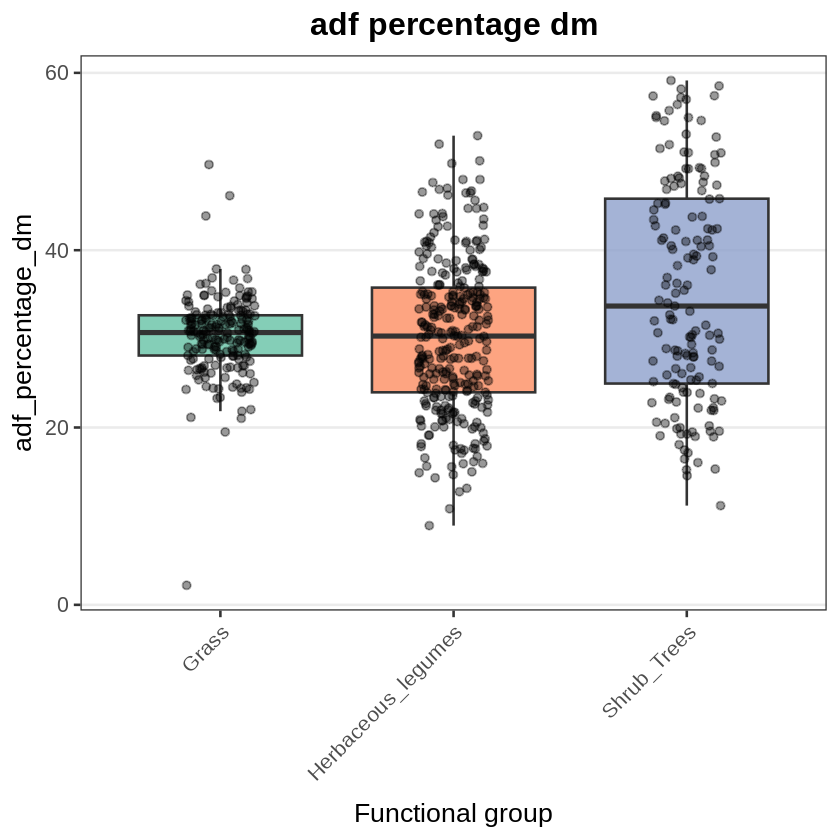

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


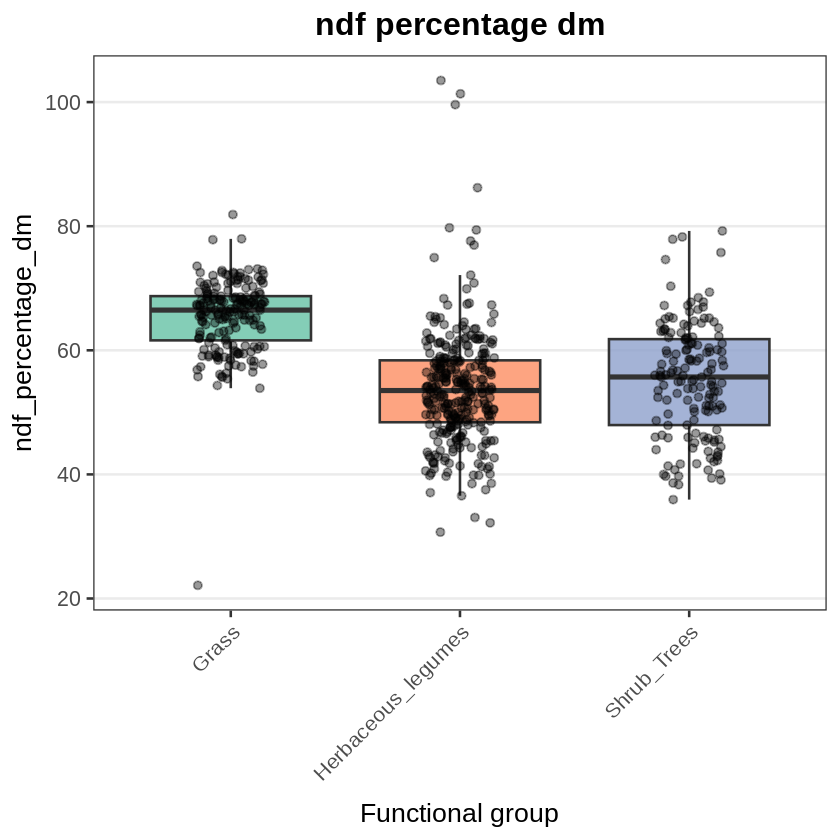

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


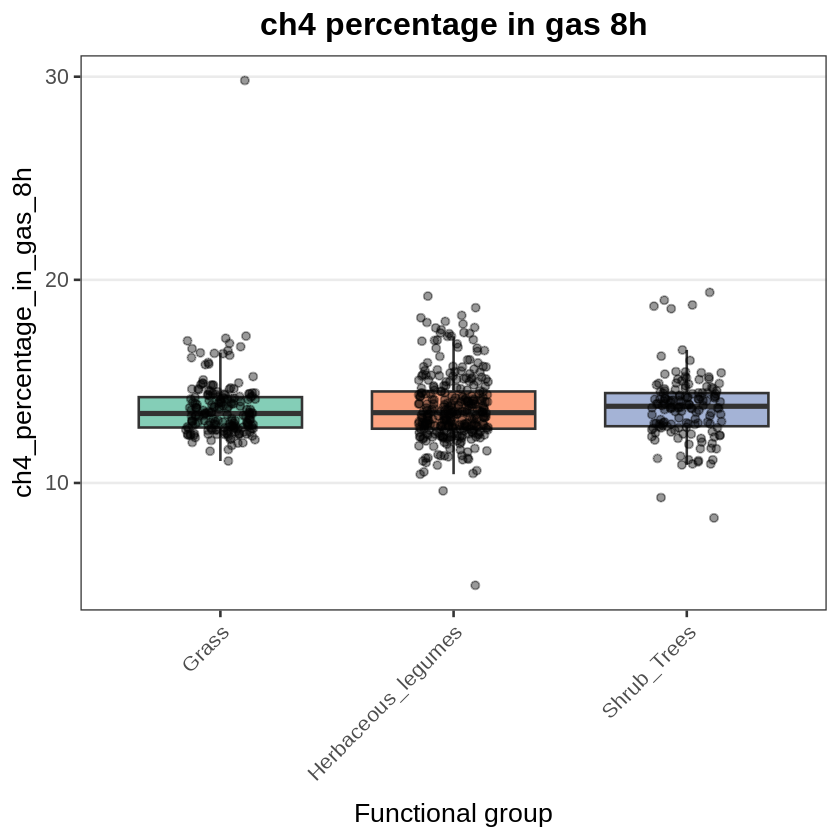

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


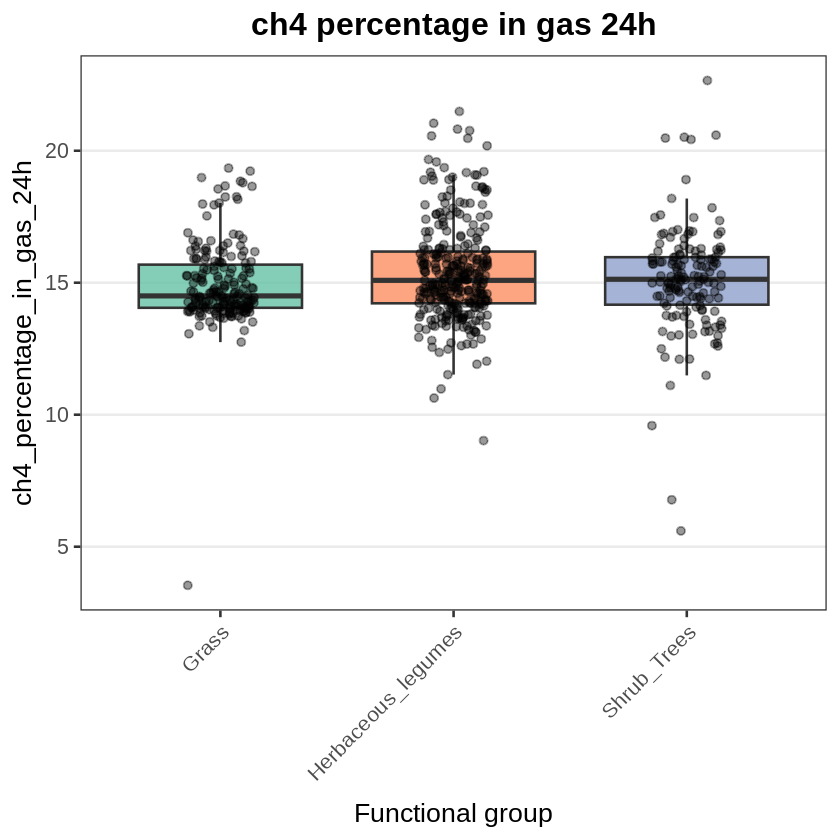

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


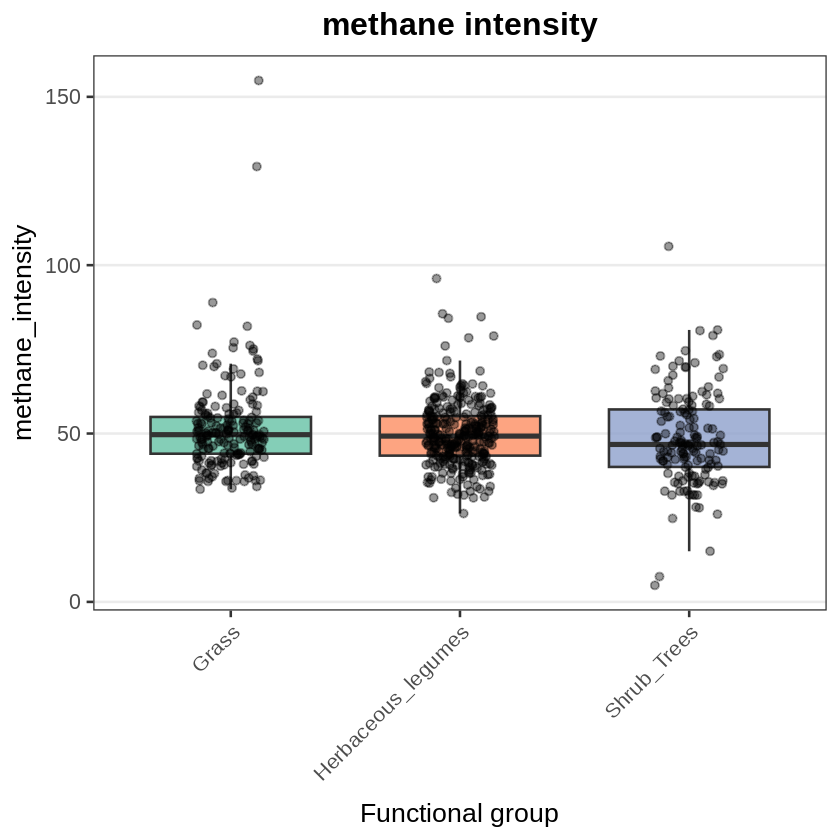

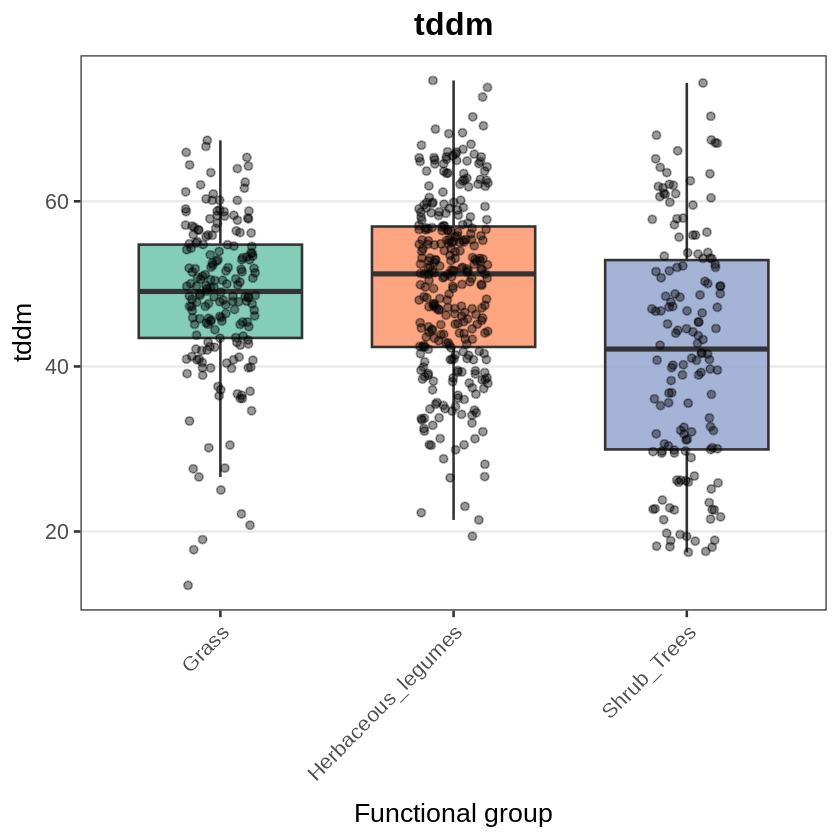

In [ ]:
vars <- c(
  "dm_percentage",
  "ash_dm",
  "om_percentage",
  "adf_percentage_dm",
  "ndf_percentage_dm",
  "ch4_percentage_in_gas_8h",
  "ch4_percentage_in_gas_24h",
  "methane_intensity",
  "tddm"
)

for (v in vars) {

  p <- ggplot(compiled, aes(x = functional_group,
                      y = .data[[v]],
                      fill = functional_group)) +
    geom_boxplot(width = 0.7, alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.15, alpha = 0.4, size = 1.8) +
    scale_fill_brewer(palette = "Set2") +
    labs(
      x = "Functional group",
      y = v,
      title = gsub("_", " ", v)
    ) +
    theme_bw(base_size = 16) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold", hjust = 0.5),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )

  print(p)
}

## 3.1 Stats by functional group

In [ ]:
cat('Mean values by functional group')
cat("\n=====================================\n")

compiled %>%
  group_by(functional_group) %>%
  summarise(
    n = n(),
    dm_percentage = mean(dm_percentage, na.rm = TRUE),
    ash_dm = mean(ash_dm, na.rm = TRUE),
    om_percentage = mean(om_percentage, na.rm = TRUE),
    adf_percentage_dm = mean(adf_percentage_dm, na.rm = TRUE),
    ndf_percentage_dm = mean(ndf_percentage_dm, na.rm = TRUE),
    ch4_percentage_in_gas_8h = mean(ch4_percentage_in_gas_8h, na.rm = TRUE),
    ch4_percentage_in_gas_24h = mean(ch4_percentage_in_gas_24h, na.rm = TRUE),
    methane_intensity = mean(methane_intensity, na.rm = TRUE),
    tddm = mean(tddm, na.rm = TRUE),

  )

Mean values by functional group


functional_group,n,dm_percentage,ash_dm,om_percentage,adf_percentage_dm,ndf_percentage_dm,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Grass,193,95.65233,13.23109,86.76886,30.33710,65.42212,13.68246,14.94429,51.61974,48.45246
Herbaceous_legumes,308,92.78344,11.54951,88.45045,30.27140,53.85140,13.69440,15.37560,49.89394,49.79033
Shrub_Trees,153,93.73222,10.07686,89.92294,35.31464,55.16608,13.70127,15.09940,48.57113,41.95287


# 4.0 Evaluation of batch effects using Star grass as a control sample

In [ ]:
# Column names
names(gas_raw)

[1] "subset"                    "no"                       
 [3] "requisitioner"             "id_lab"                   
 [5] "id"                        "tax_order"                
 [7] "family"                    "genus"                    
 [9] "species"                   "tax_name"                 
[11] "functional_group"          "set_ciat"                 
[13] "batch"                     "run"                      
[15] "replication"               "syrange"                  
[17] "sample_weight_g"           "undigested_dm_g"          
[19] "dm_incubated"              "digested_feed_mg"         
[21] "net_gas_8h_ml"             "net_gas_24h_ml"           
[23] "ch4_8h_ml"                 "ch4_24h_ml"               
[25] "ch4_percentage_in_gas_8h"  "ch4_percentage_in_gas_24h"
[27] "gas_ml_g_dm_incubated_24h" "part_fact"                
[29] "ch4_ml_g_dm_incubated_24h" "ch4_ml_g_ndf_digested_24h"
[31] "methane_intensity"         "tddm"                     
[33] "information_remarks_1"     "information_remarks_2"    
[35] "gas_remarks_1"             "gas_remarks_2"            
[37] "digest_remarks_1"          "digest_remarks_2"         
[39] "delete"

In [ ]:
# Star grass dataframe
star_grass <- gas_raw %>%
  filter(id_lab == "F25-0008")

head(star_grass)

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,⋯,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2,delete
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>
1,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,,,NA,,,no
2,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,"30,31,32",,NA,,,no
3,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,"33,34,35",,NA,,,no
4,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,"36,37,38",,NA,,,no
5,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,"42,43,47",,NA,,,no
6,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.1010242,164.3696,12.53515,,"45,46,47",,NA,,,no


### 4.1 Analyses of variance

In [ ]:
# Anova for one variable
cat('Anova for net_gas_8h_ml')
cat("\n==========================\n")
modelo <- lm(net_gas_8h_ml ~ factor(batch), data = star_grass)
anova(modelo)

Anova for net_gas_8h_ml


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
factor(batch),34,3077.207,90.506076,16.52924,9.833227e-61
Residuals,479,2622.772,5.475515,NA,NA


In [ ]:
shapiro.test(residuals(modelo))


	Shapiro-Wilk normality test

data:  residuals(modelo)
W = 0.91211, p-value < 2.2e-16


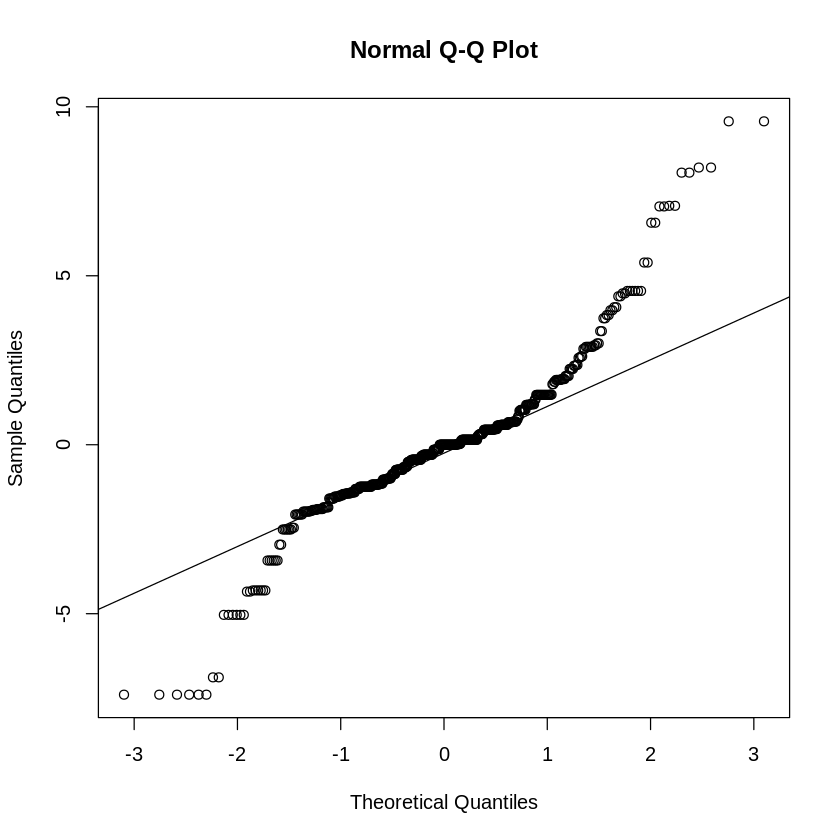

In [ ]:
qqnorm(residuals(modelo))
qqline(residuals(modelo))

In [ ]:
leveneTest(net_gas_24h_ml ~ factor(batch), data = star_grass)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,34,4.708212,2.982628e-15
,479,NA,NA


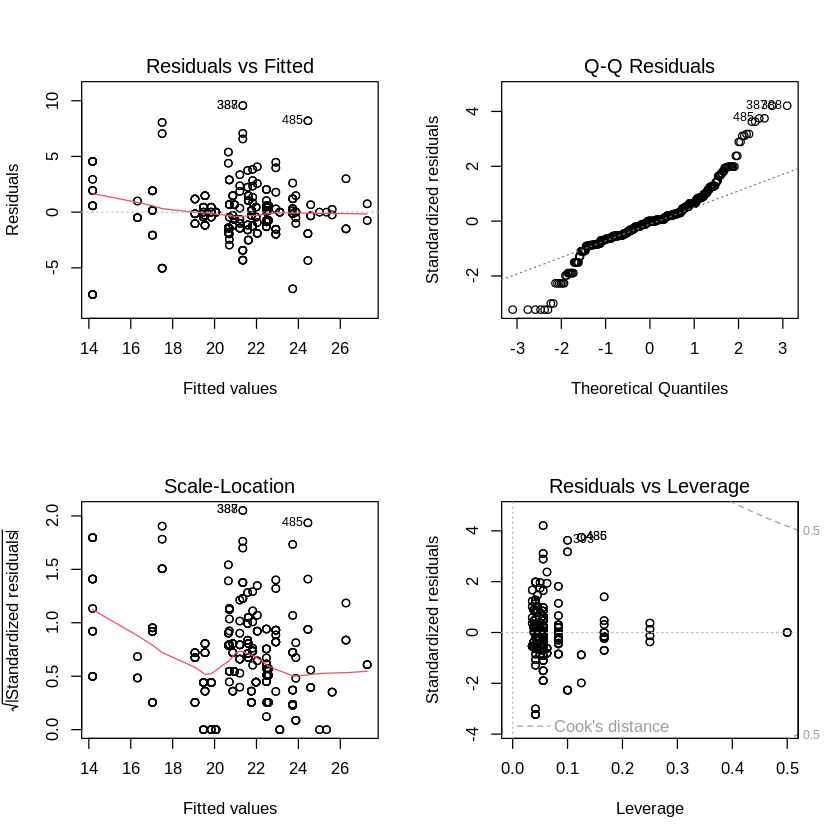

In [ ]:
par(mfrow = c(2,2))
plot(modelo)

In [ ]:
# Quantitative variables to analyze
variables <-c('undigested_dm_g','dm_incubated','digested_feed_mg','net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml',
              'ch4_percentage_in_gas_8h','ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h','part_fact',
              'ch4_ml_g_dm_incubated_24h','methane_intensity','tddm') # 'ch4_ml_g_ndf_digested_24h' was removed from the list due to extrange data in some cells

In [ ]:
# Anovas for all quantitative variables
for (var in variables) {

  cat("\n=====================================\n")
  cat(var, "\n")
  cat("=====================================\n")

  linear_model <- lm(
    as.formula(paste(var, "~ factor(batch)")),
    data = star_grass
  )

  print(anova(linear_model))
}


undigested_dm_g 
Analysis of Variance Table

Response: undigested_dm_g
               Df  Sum Sq   Mean Sq F value    Pr(>F)    
factor(batch)  34 0.49661 0.0146061  4.6956 3.394e-15 ***
Residuals     479 1.48997 0.0031106                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

dm_incubated 
Analysis of Variance Table

Response: dm_incubated
               Df Sum Sq Mean Sq F value    Pr(>F)    
factor(batch)  34 213567  6281.4  86.931 < 2.2e-16 ***
Residuals     453  32733    72.3                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

digested_feed_mg 
Analysis of Variance Table

Response: digested_feed_mg
               Df Sum Sq Mean Sq F value    Pr(>F)    
factor(batch)  34 527022 15500.7  9.4118 < 2.2e-16 ***
Residuals     453 746064  1646.9                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

net_gas_8h_ml 
Analysis of Variance Table

Response: net_gas_8h_ml
               

In [ ]:
# ANOVA statistics for all variables, summarized in a table
anova_results <- data.frame(
  variable = character(),
  F = numeric(),
  p = numeric()
)

for (var in variables) {

  linear_model <- lm(
    as.formula(paste(var, "~ factor(batch)")),
    data = star_grass
  )

  aov_tab <- anova(linear_model)

  anova_results <- rbind(
    anova_results,
    data.frame(
      variable = var,
      F = aov_tab$`F value`[1],
      p = aov_tab$`Pr(>F)`[1]
    )
  )
}

anova_results

variable,F,p
<chr>,<dbl>,<dbl>
undigested_dm_g,4.695607,3.393786e-15
dm_incubated,86.930880,1.274356e-175
digested_feed_mg,9.411794,9.232698e-35
net_gas_8h_ml,16.529235,9.833227e-61
net_gas_24h_ml,17.068783,1.891051e-62
ch4_8h_ml,20.651134,3.309537e-73
ch4_24h_ml,18.286797,3.153712e-66
ch4_percentage_in_gas_8h,22.739635,5.119188e-79
ch4_percentage_in_gas_24h,25.647083,1.293154e-86


### 4.2 Visualization

In [ ]:
# Boxplot function
plot_batch_boxplot <- function(data, variable) {

  ggplot(
    data,
    aes(
      x = factor(batch),
      y = .data[[variable]]
    )
  ) +
    geom_boxplot(
      width = 0.7,
      alpha = 0.8,
      outlier.shape = NA
    ) +
    geom_jitter(
      width = 0.15,
      alpha = 0.4,
      size = 2.2
    ) +
    labs(
      x = "Batch",
      y = gsub("_", " ", variable),
      title = paste("Effect of batch on", gsub("_", " ", variable))
    ) +
    theme_bw(base_size = 20) +
    theme(
      legend.position = "none",
      plot.title = element_text(size = 26, face = "bold", hjust = 0.5),
      axis.title = element_text(size = 22, face = "bold"),
      axis.text.x = element_text(size = 18, angle = 45, hjust = 1),
      axis.text.y = element_text(size = 18),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )
}

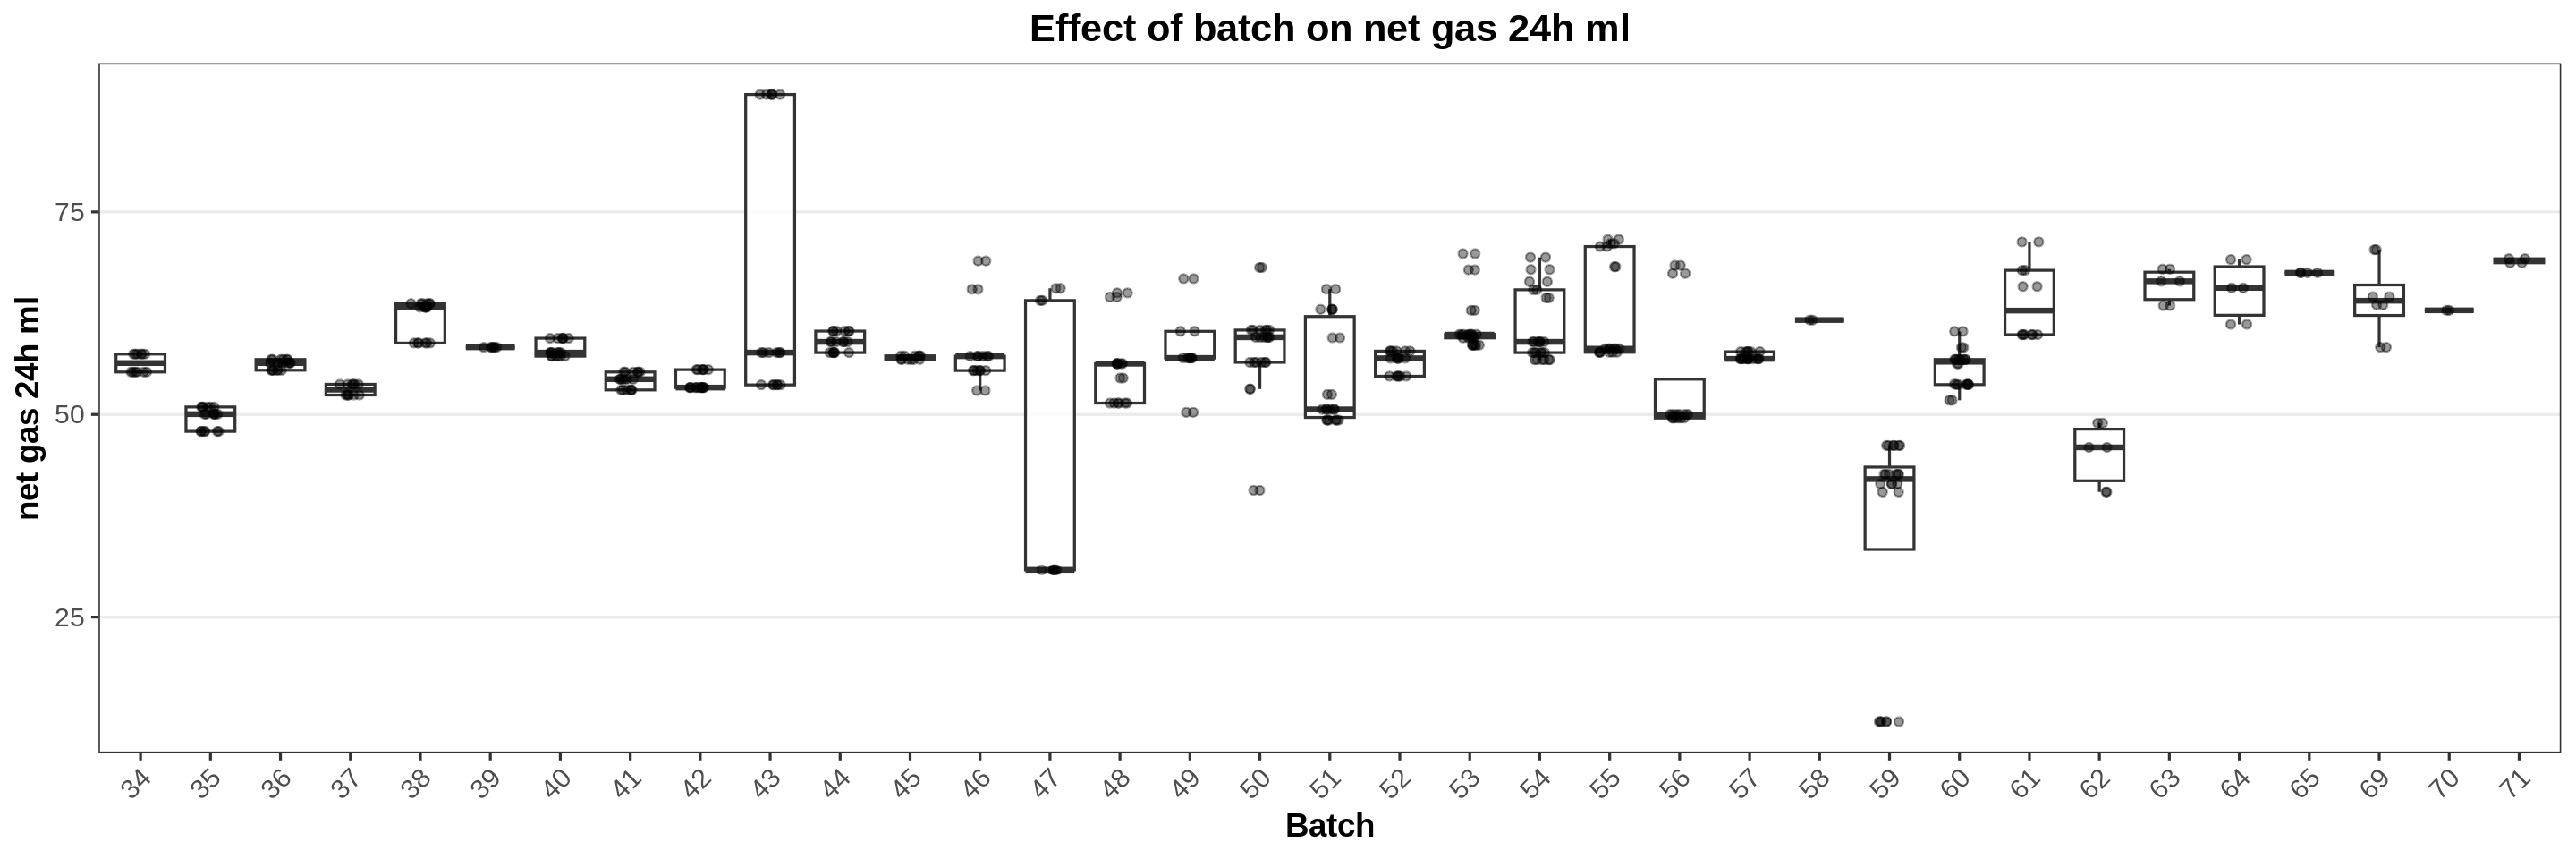

In [ ]:
# One variable boxplot
v <- "net_gas_24h_ml"
options(repr.plot.width = 24, repr.plot.height = 8)
plot_batch_boxplot(star_grass, v)

Warning message:
“Removed 26 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`).”


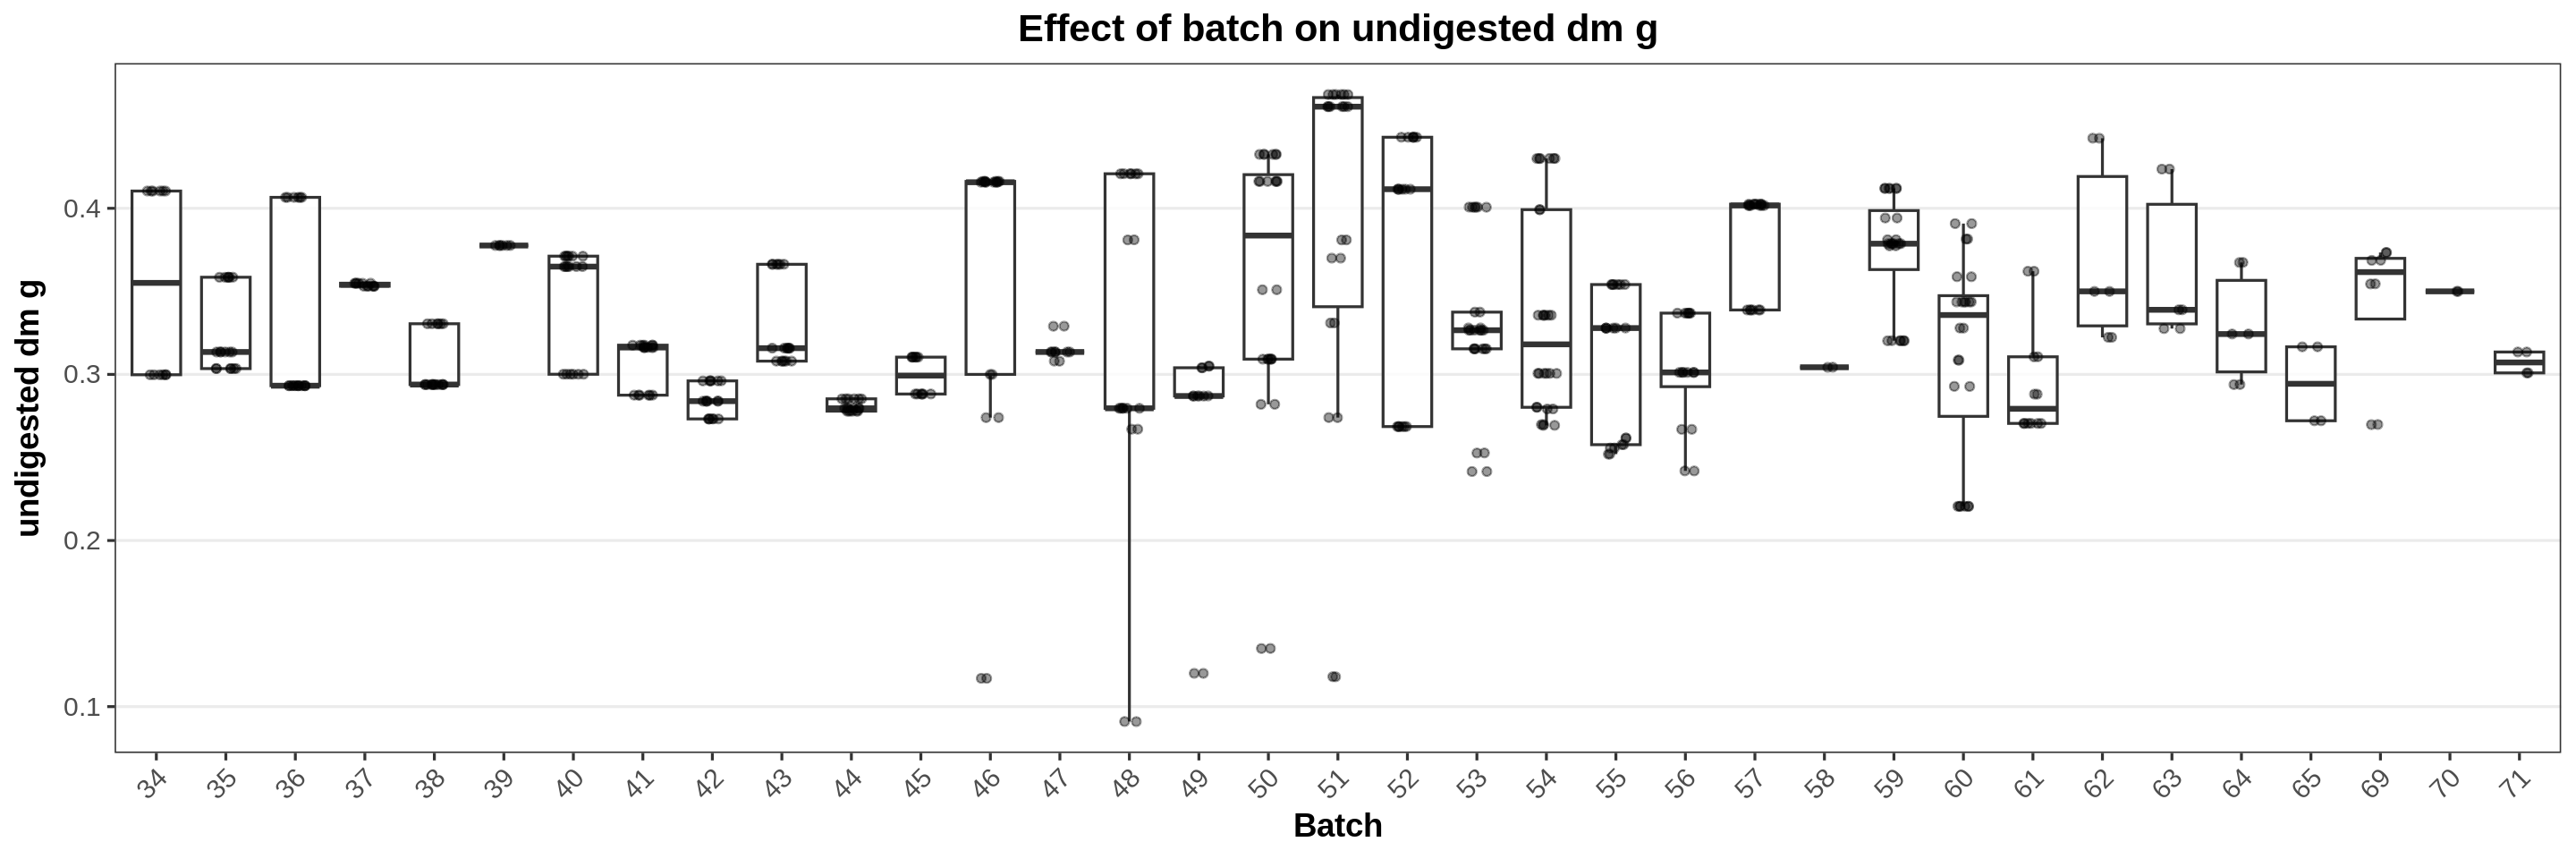

Warning message:
“Removed 26 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`).”


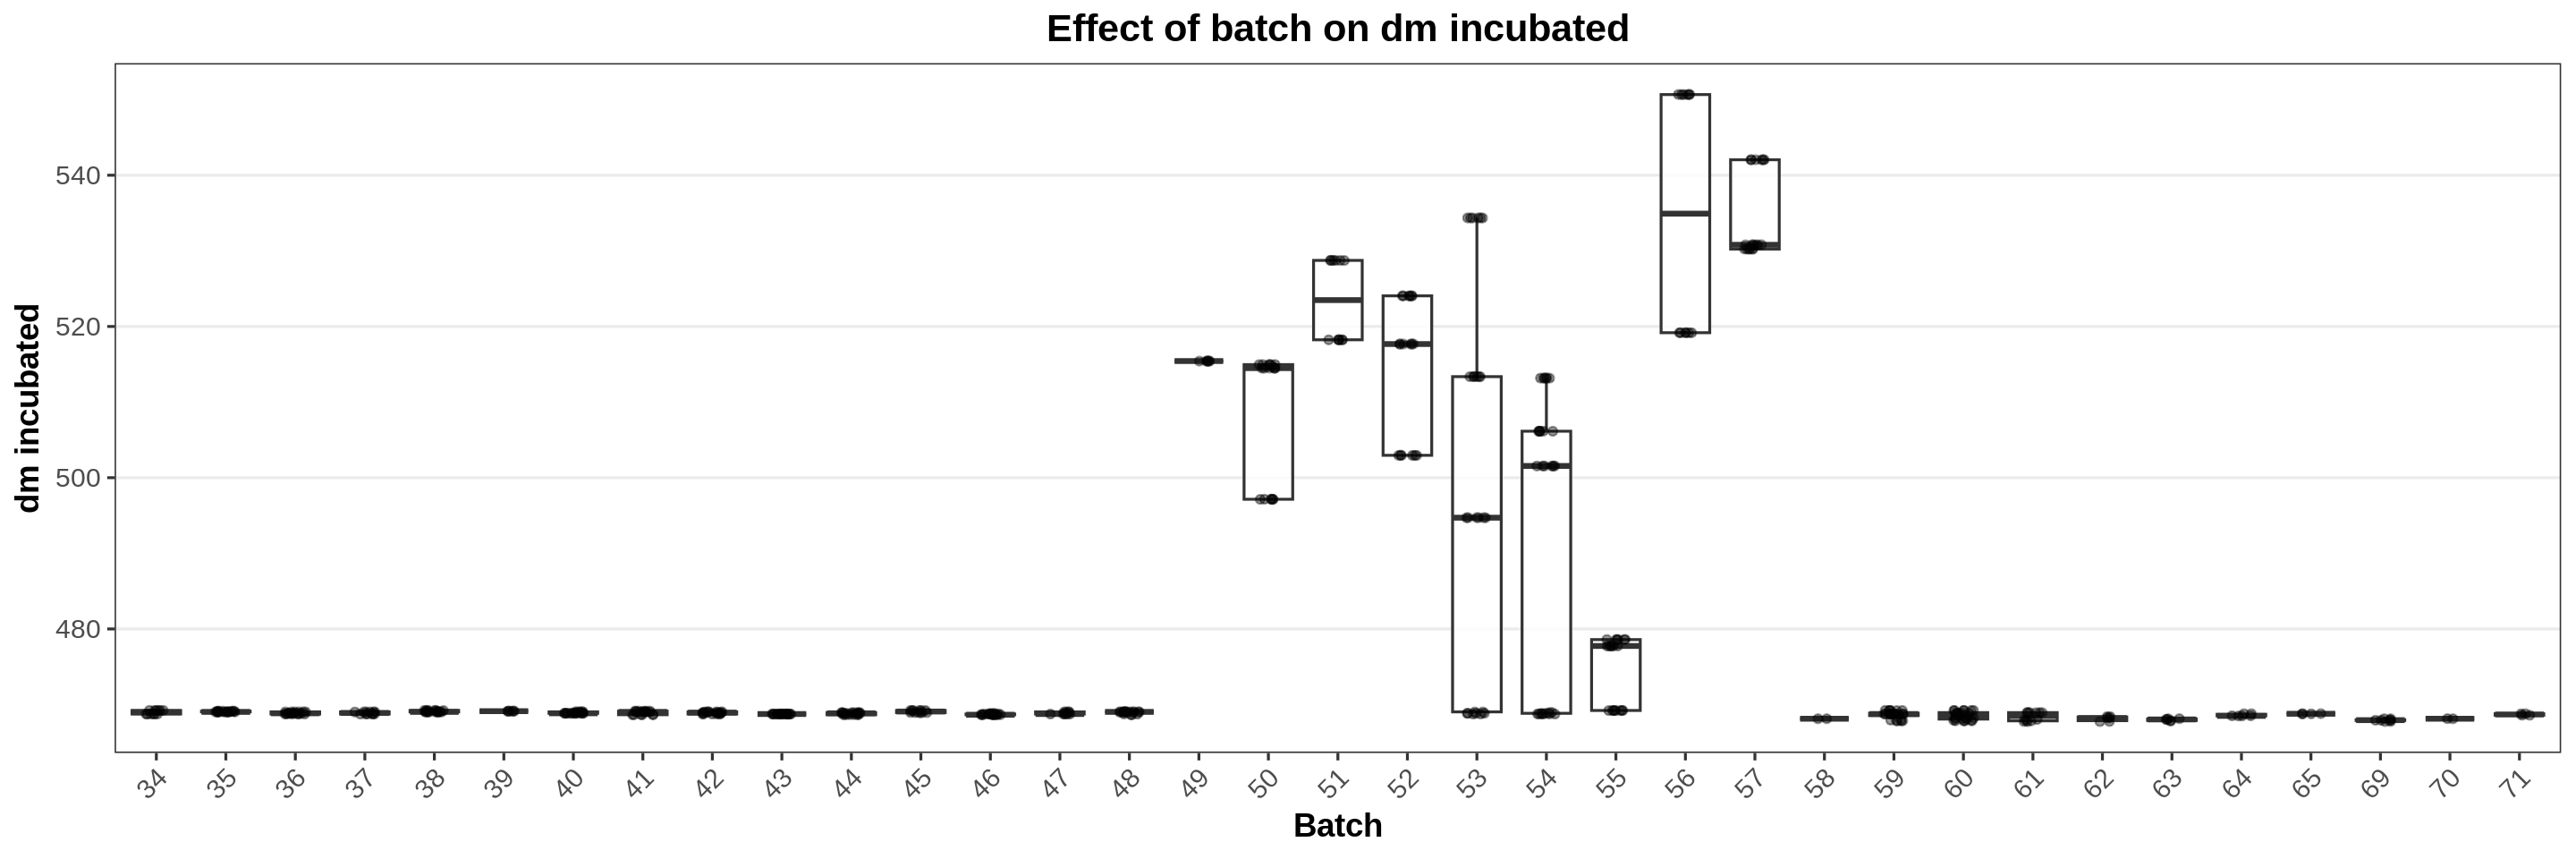

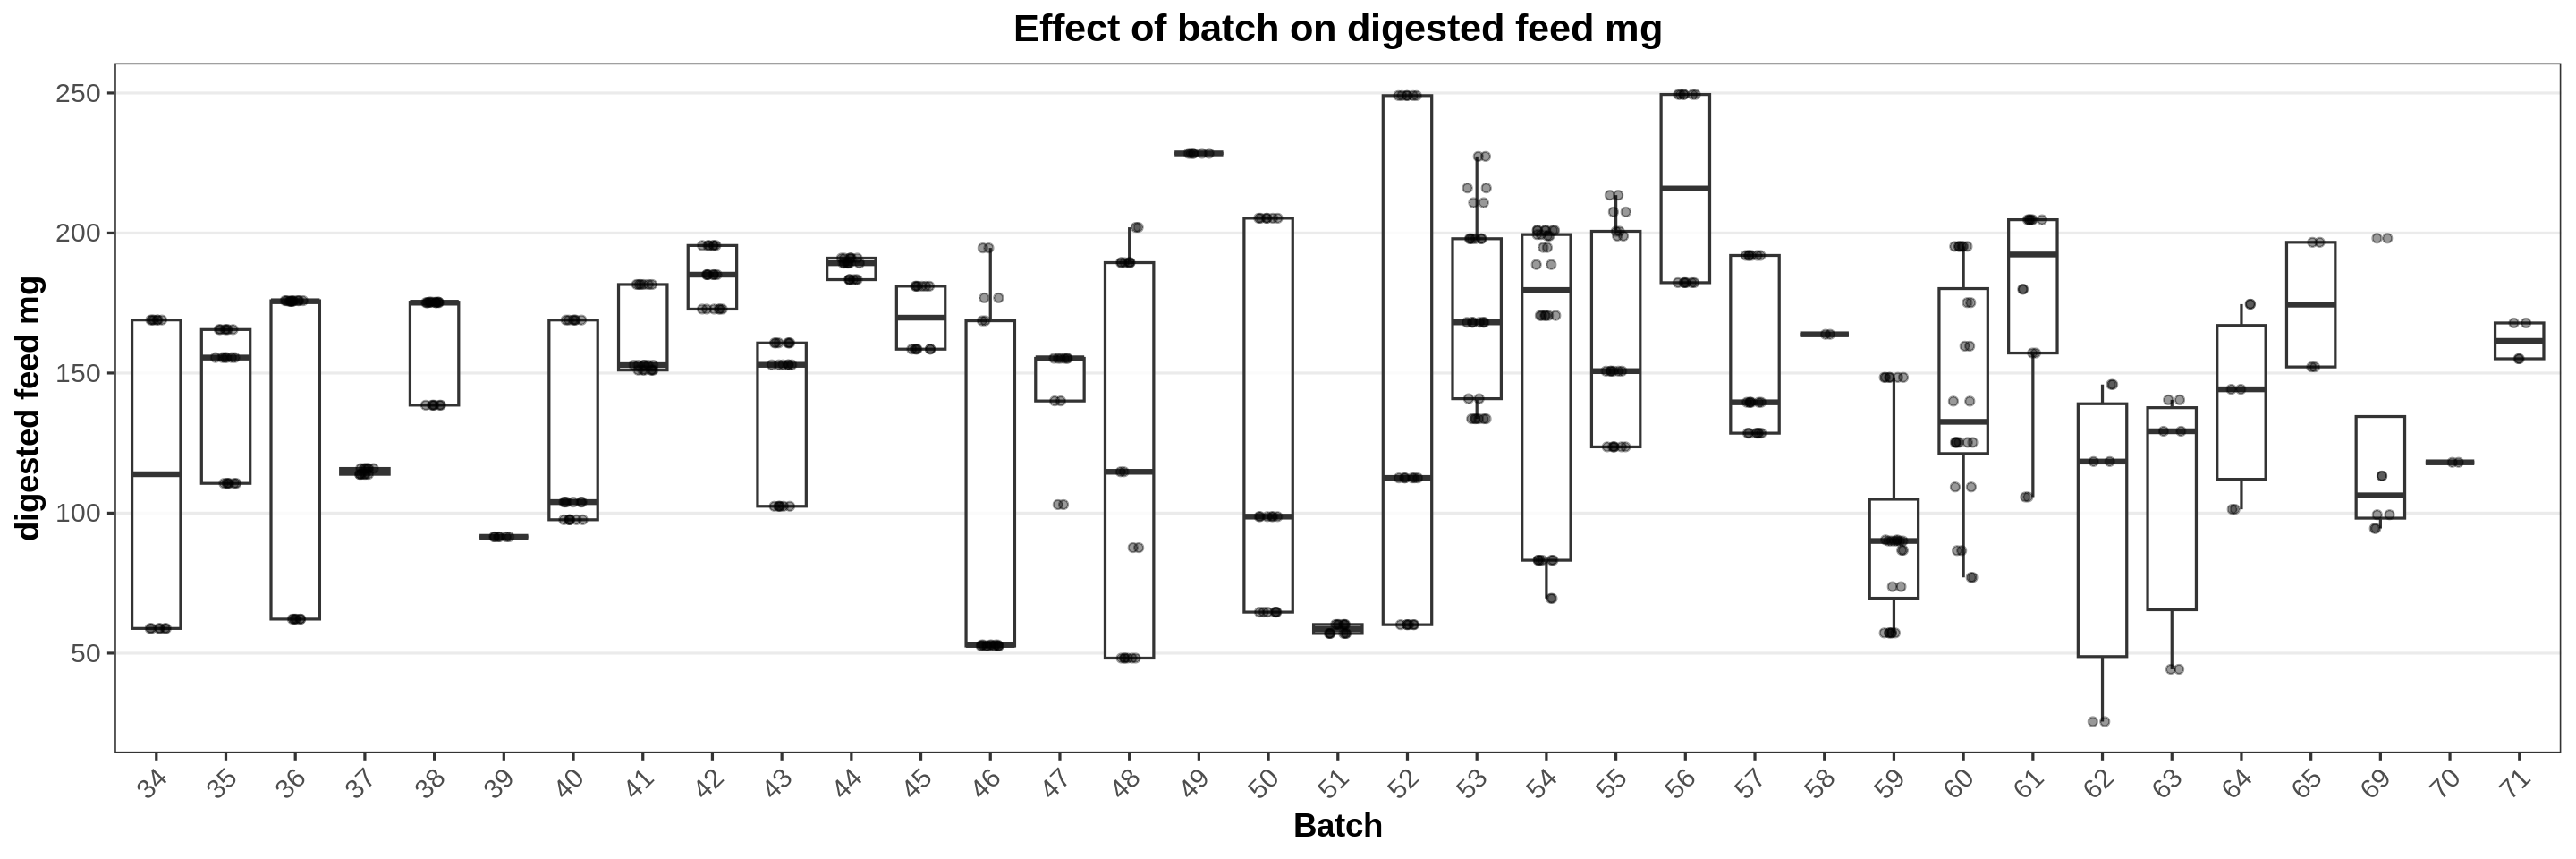

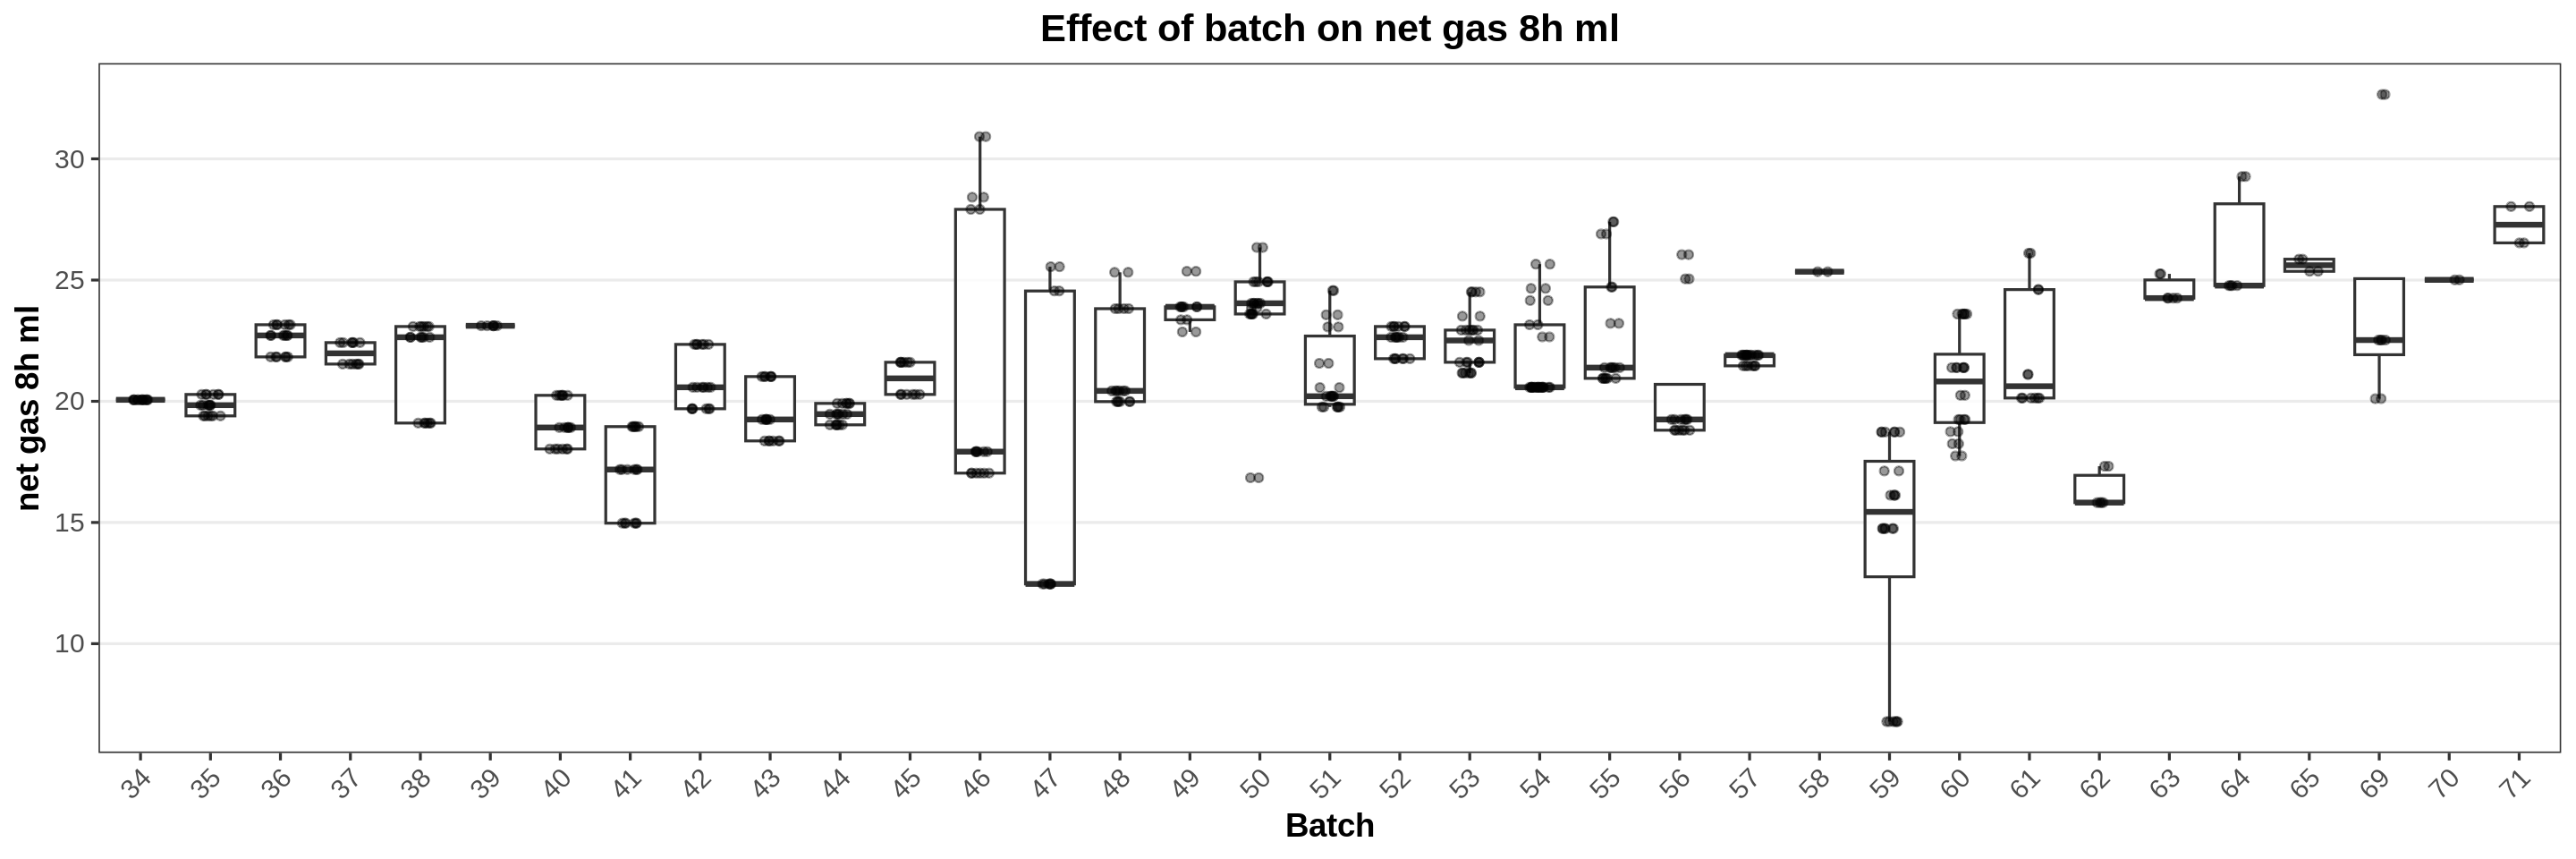

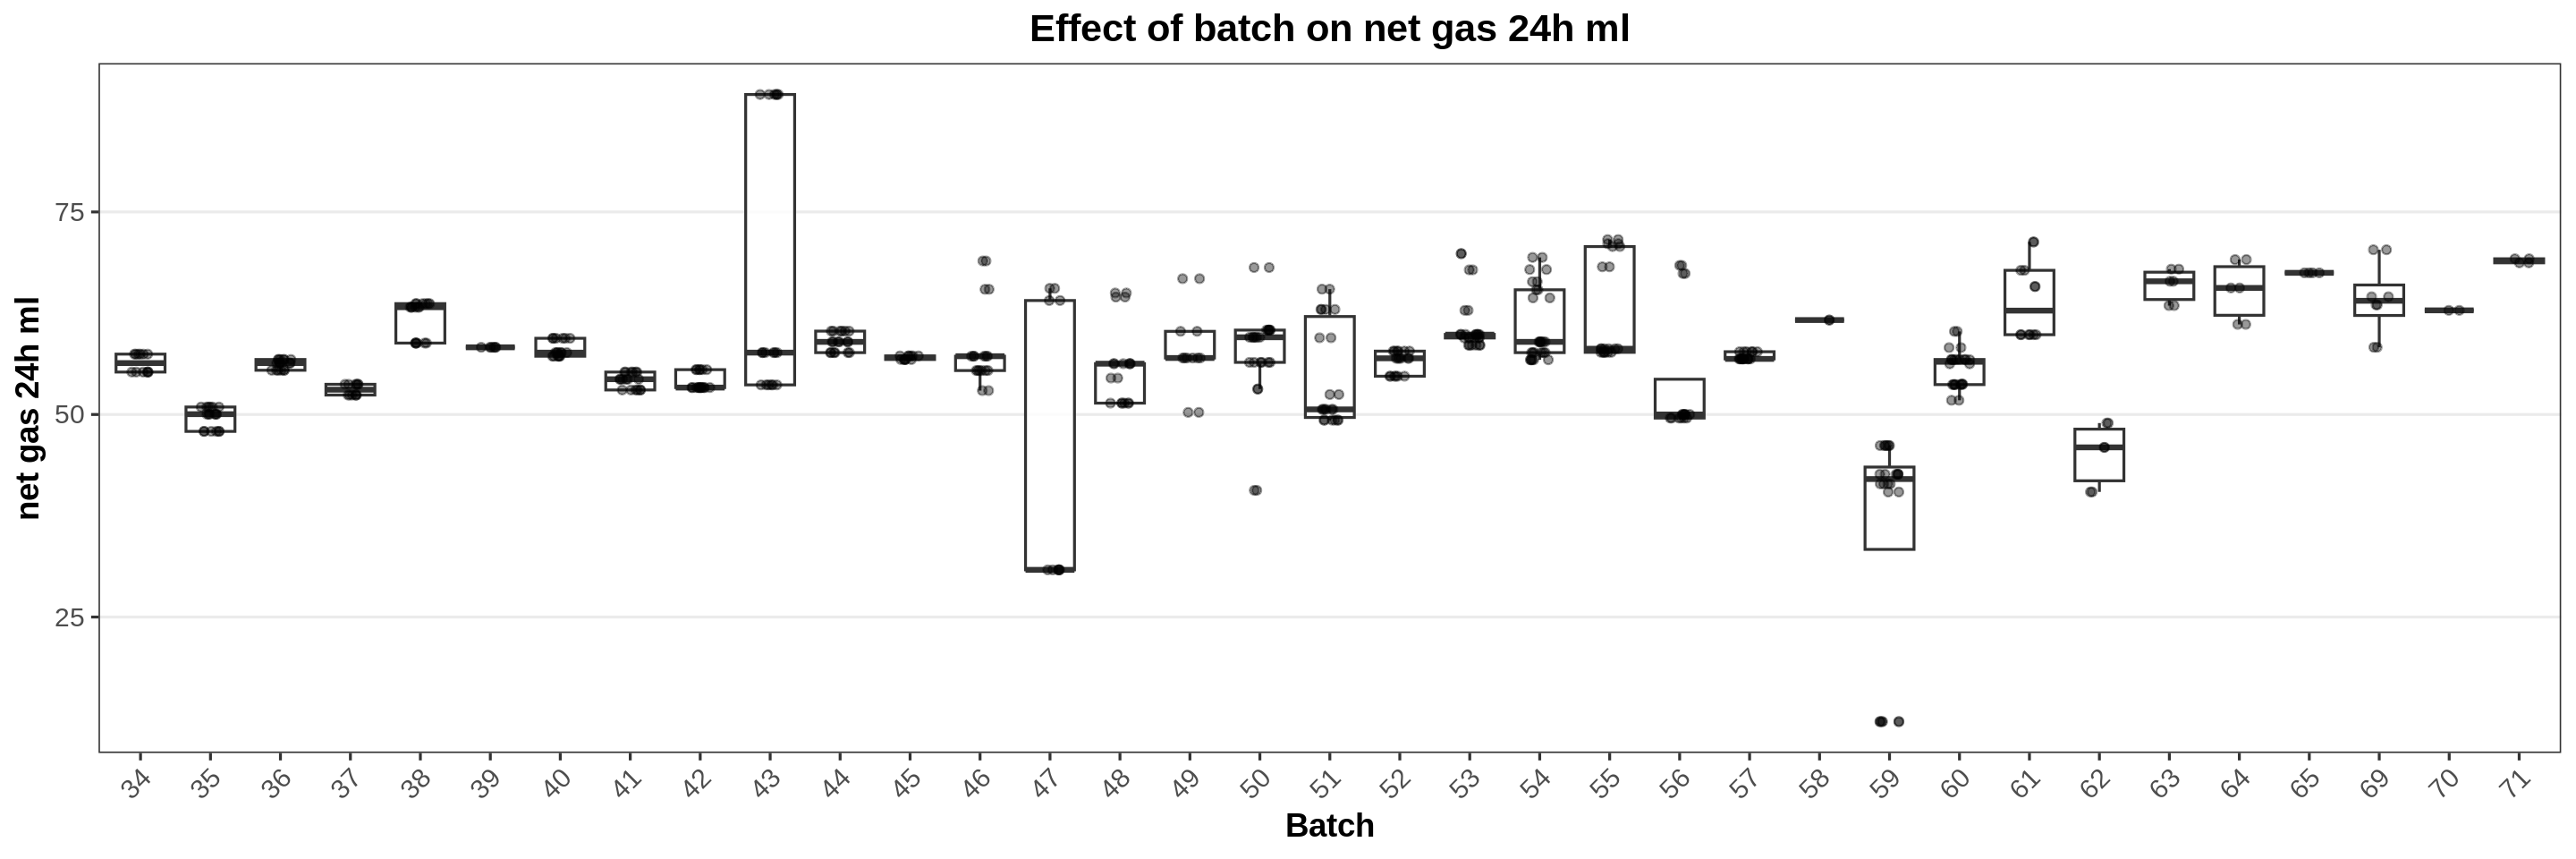

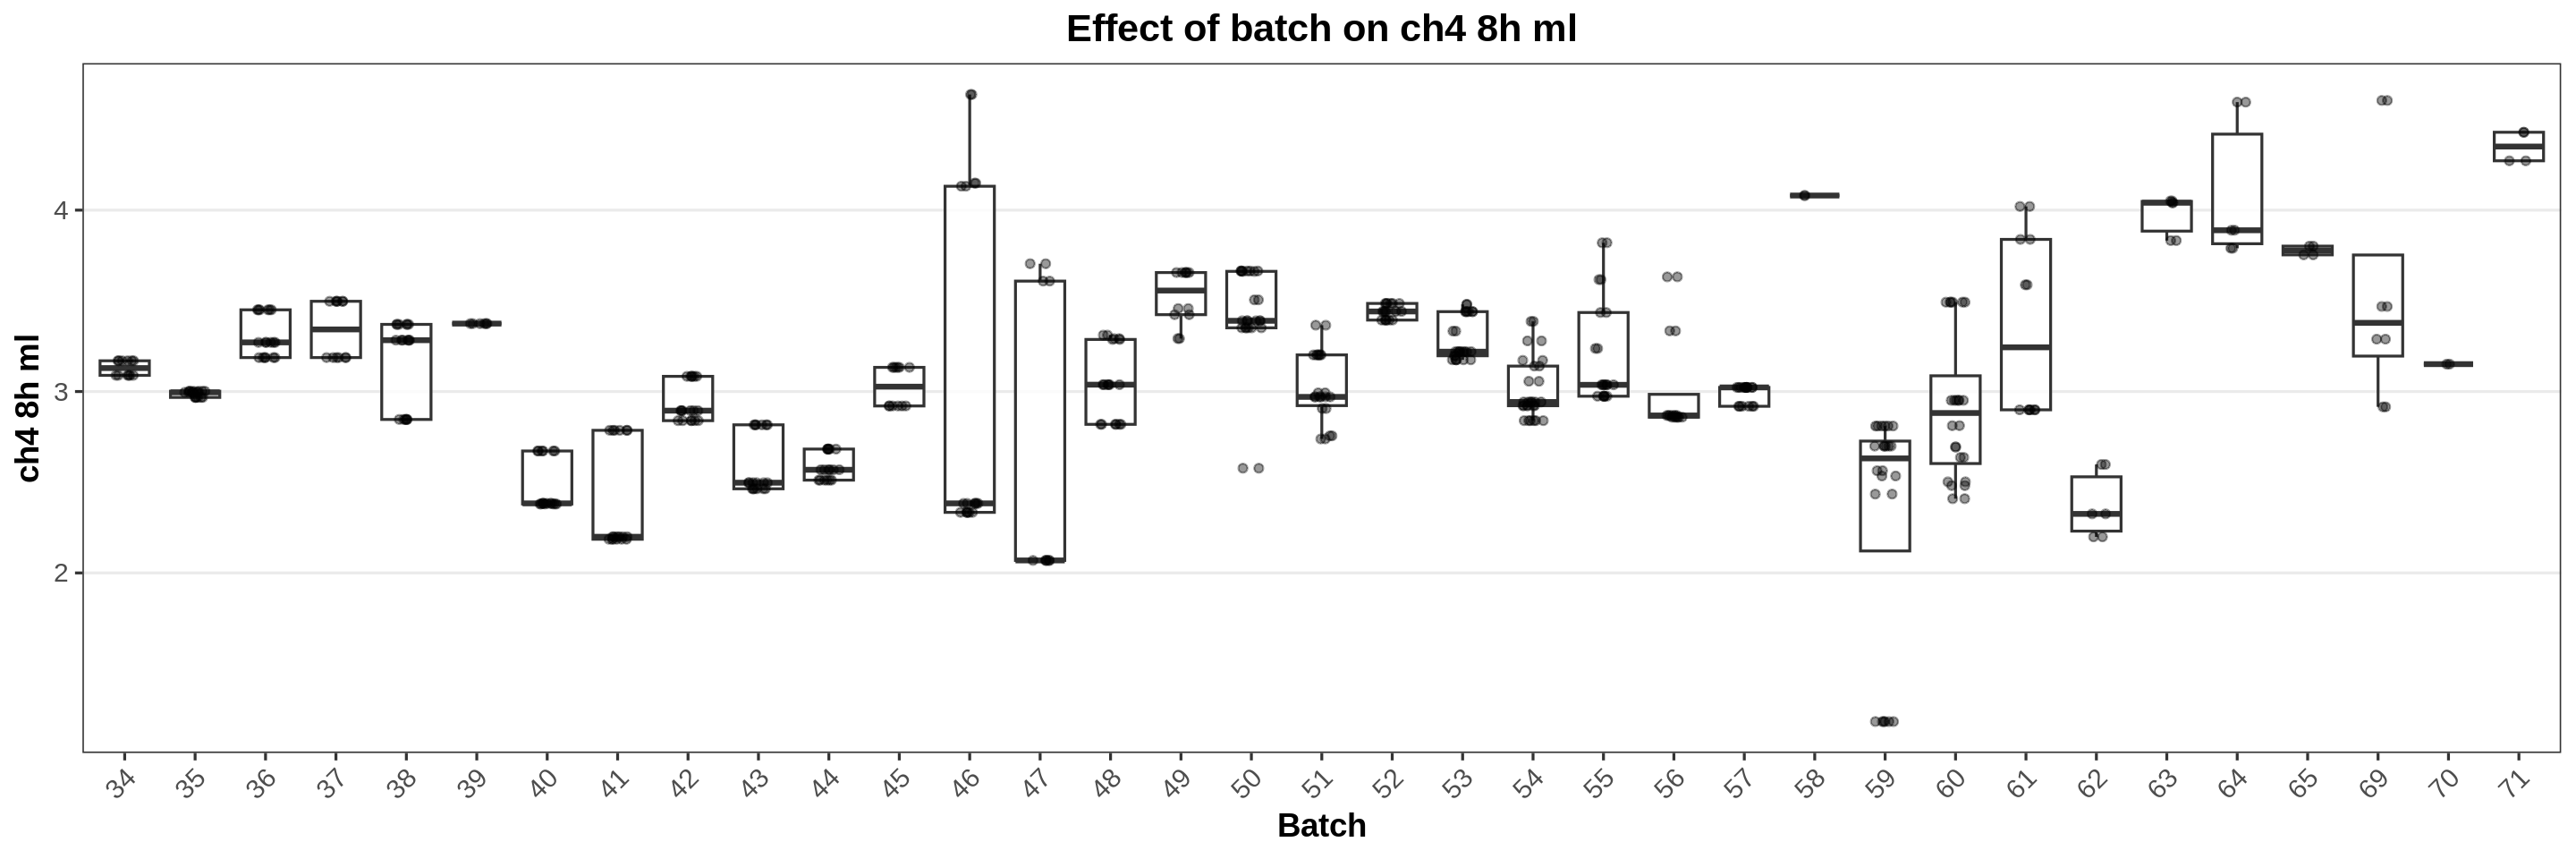

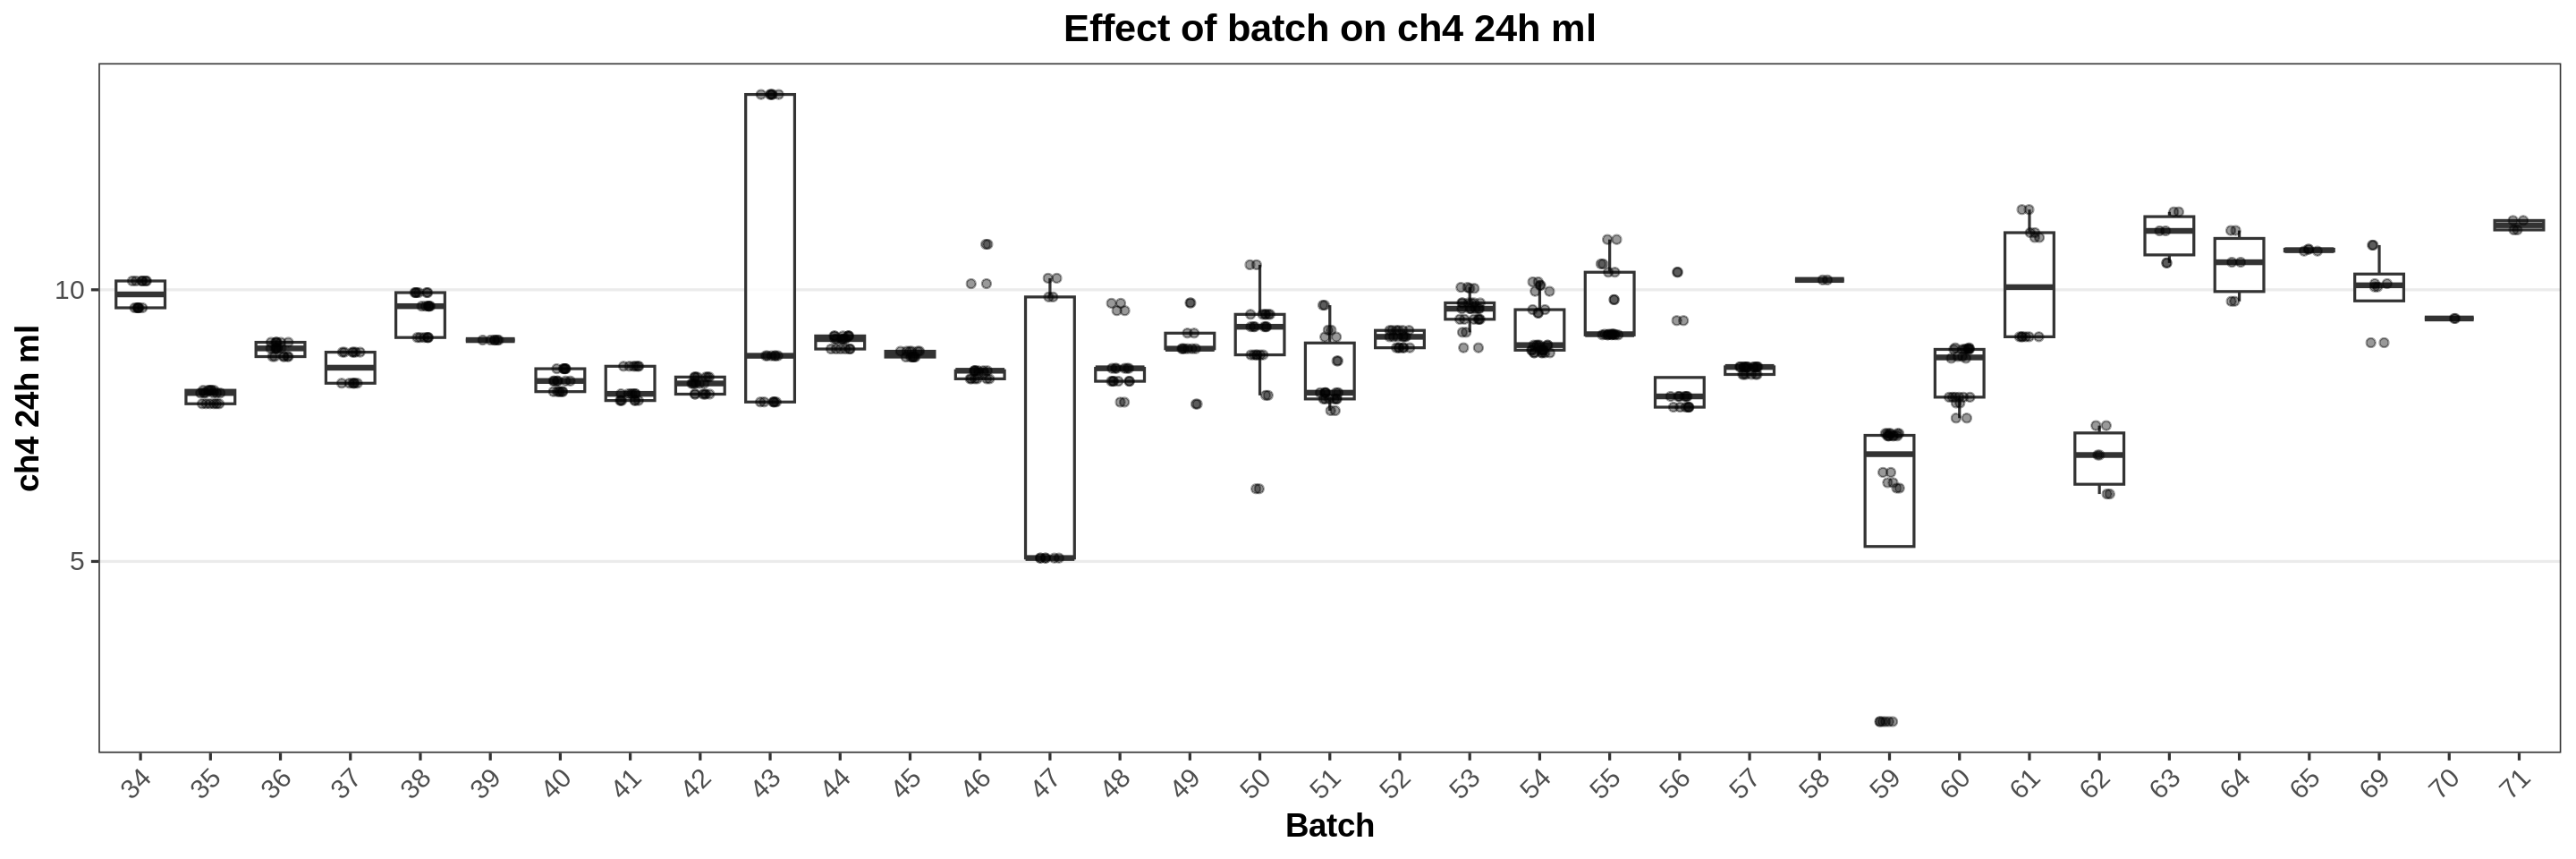

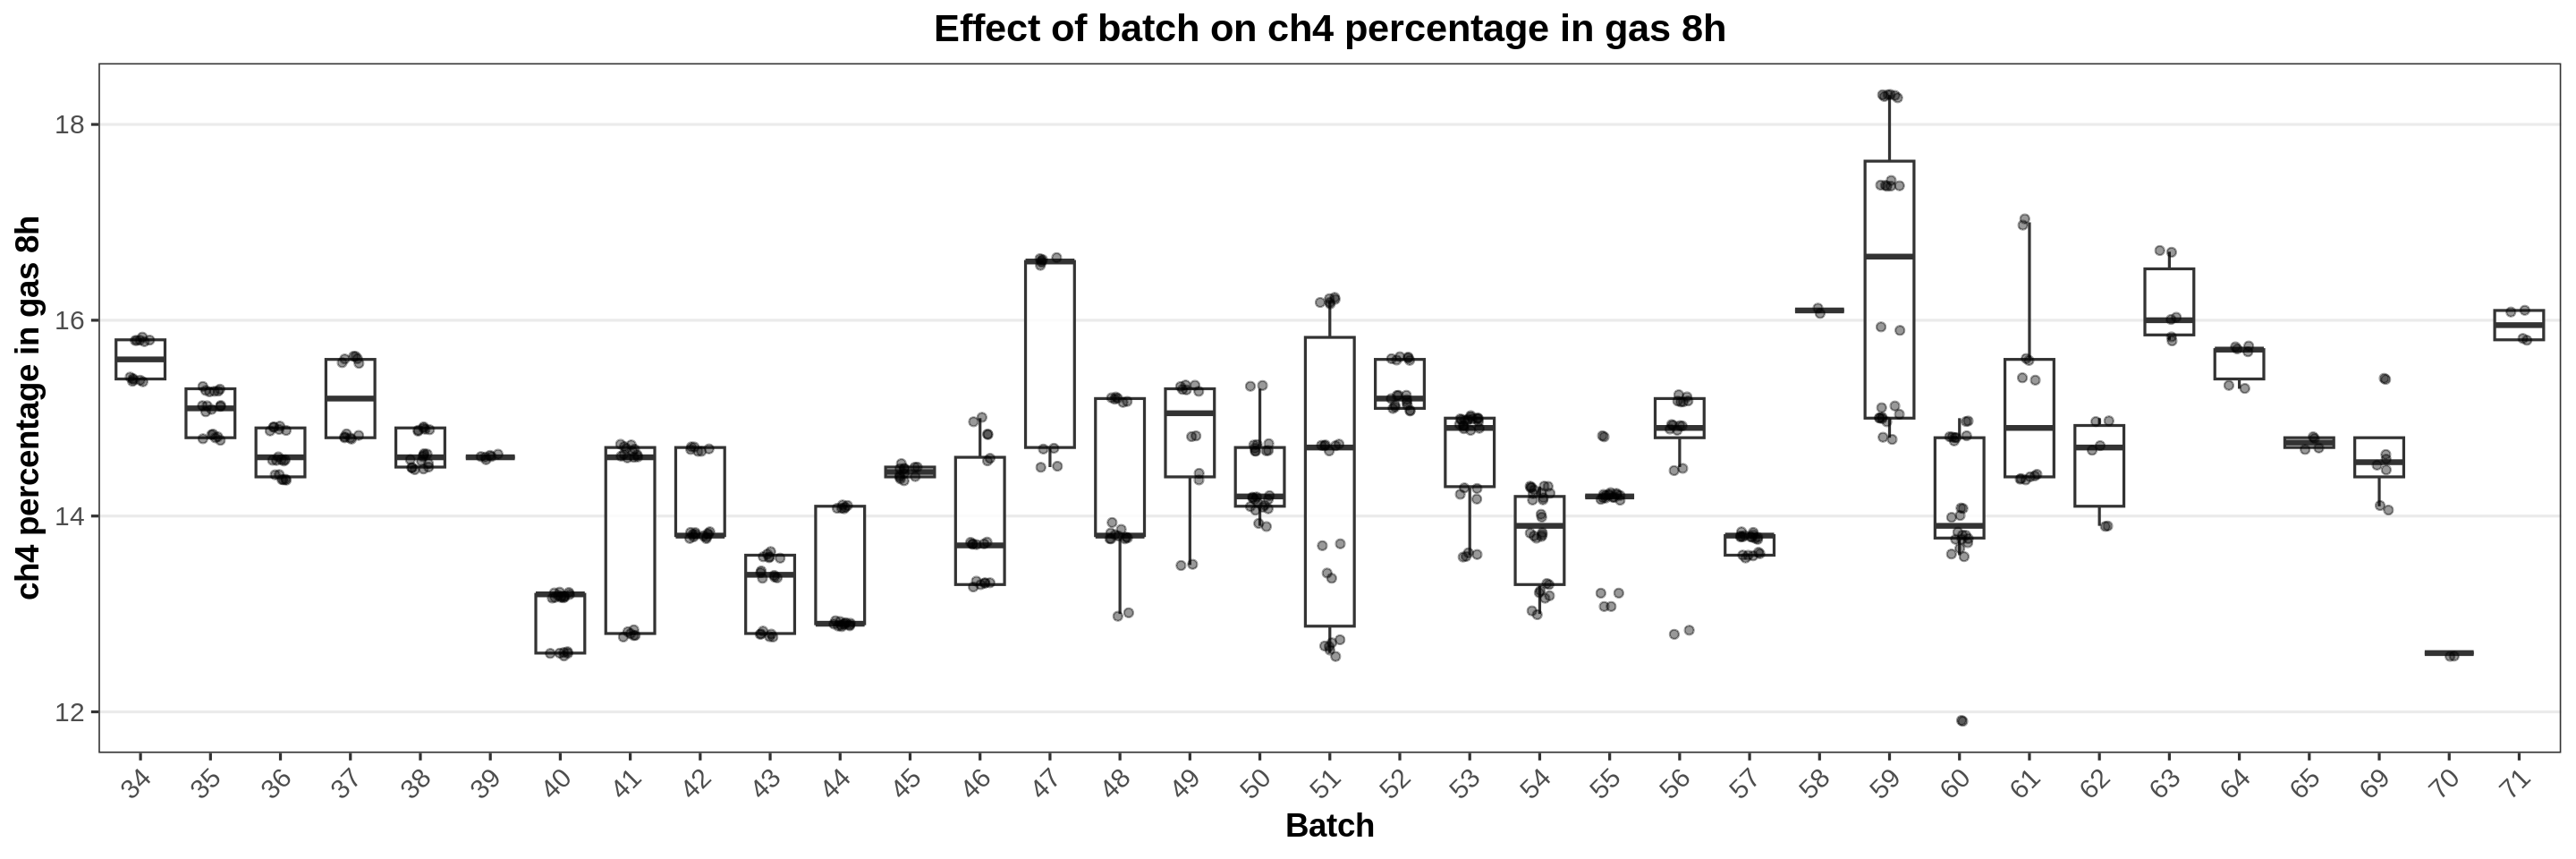

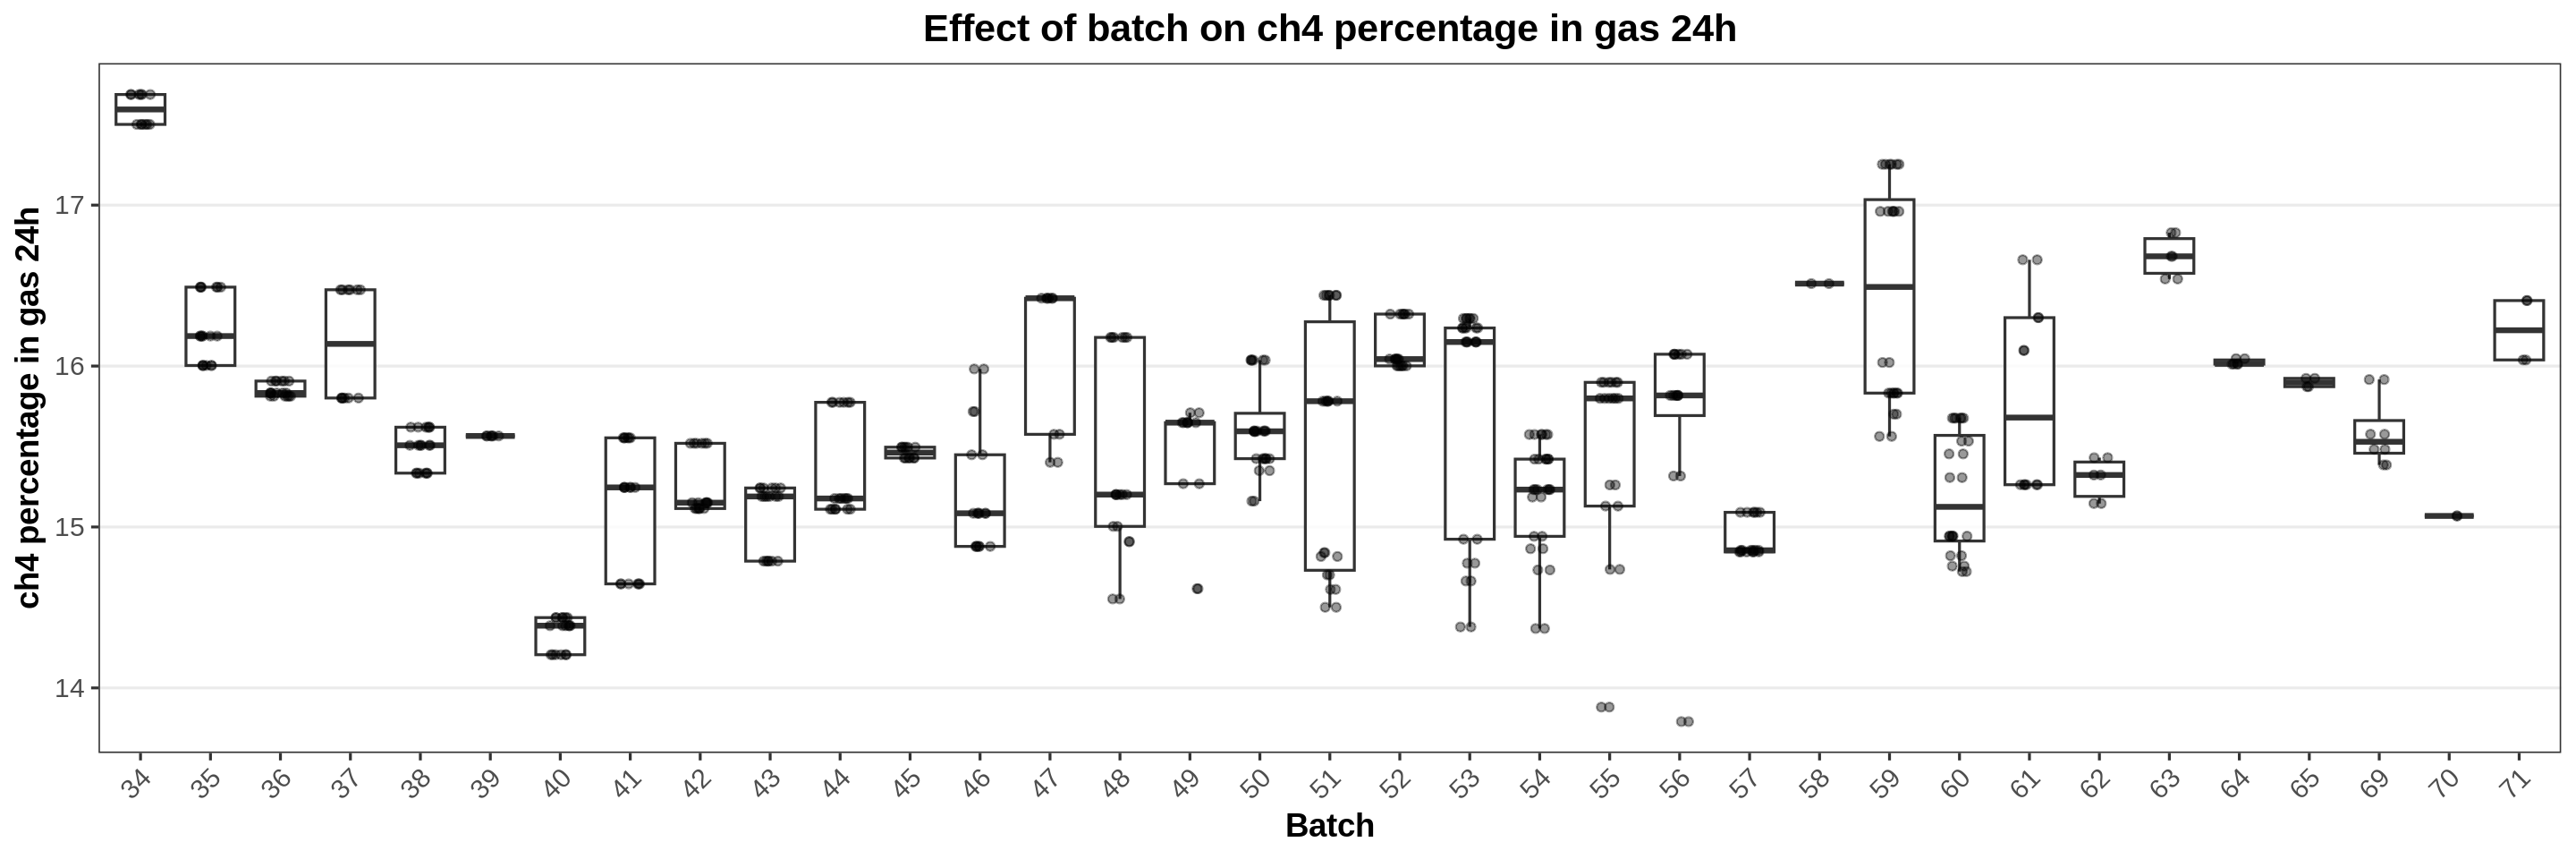

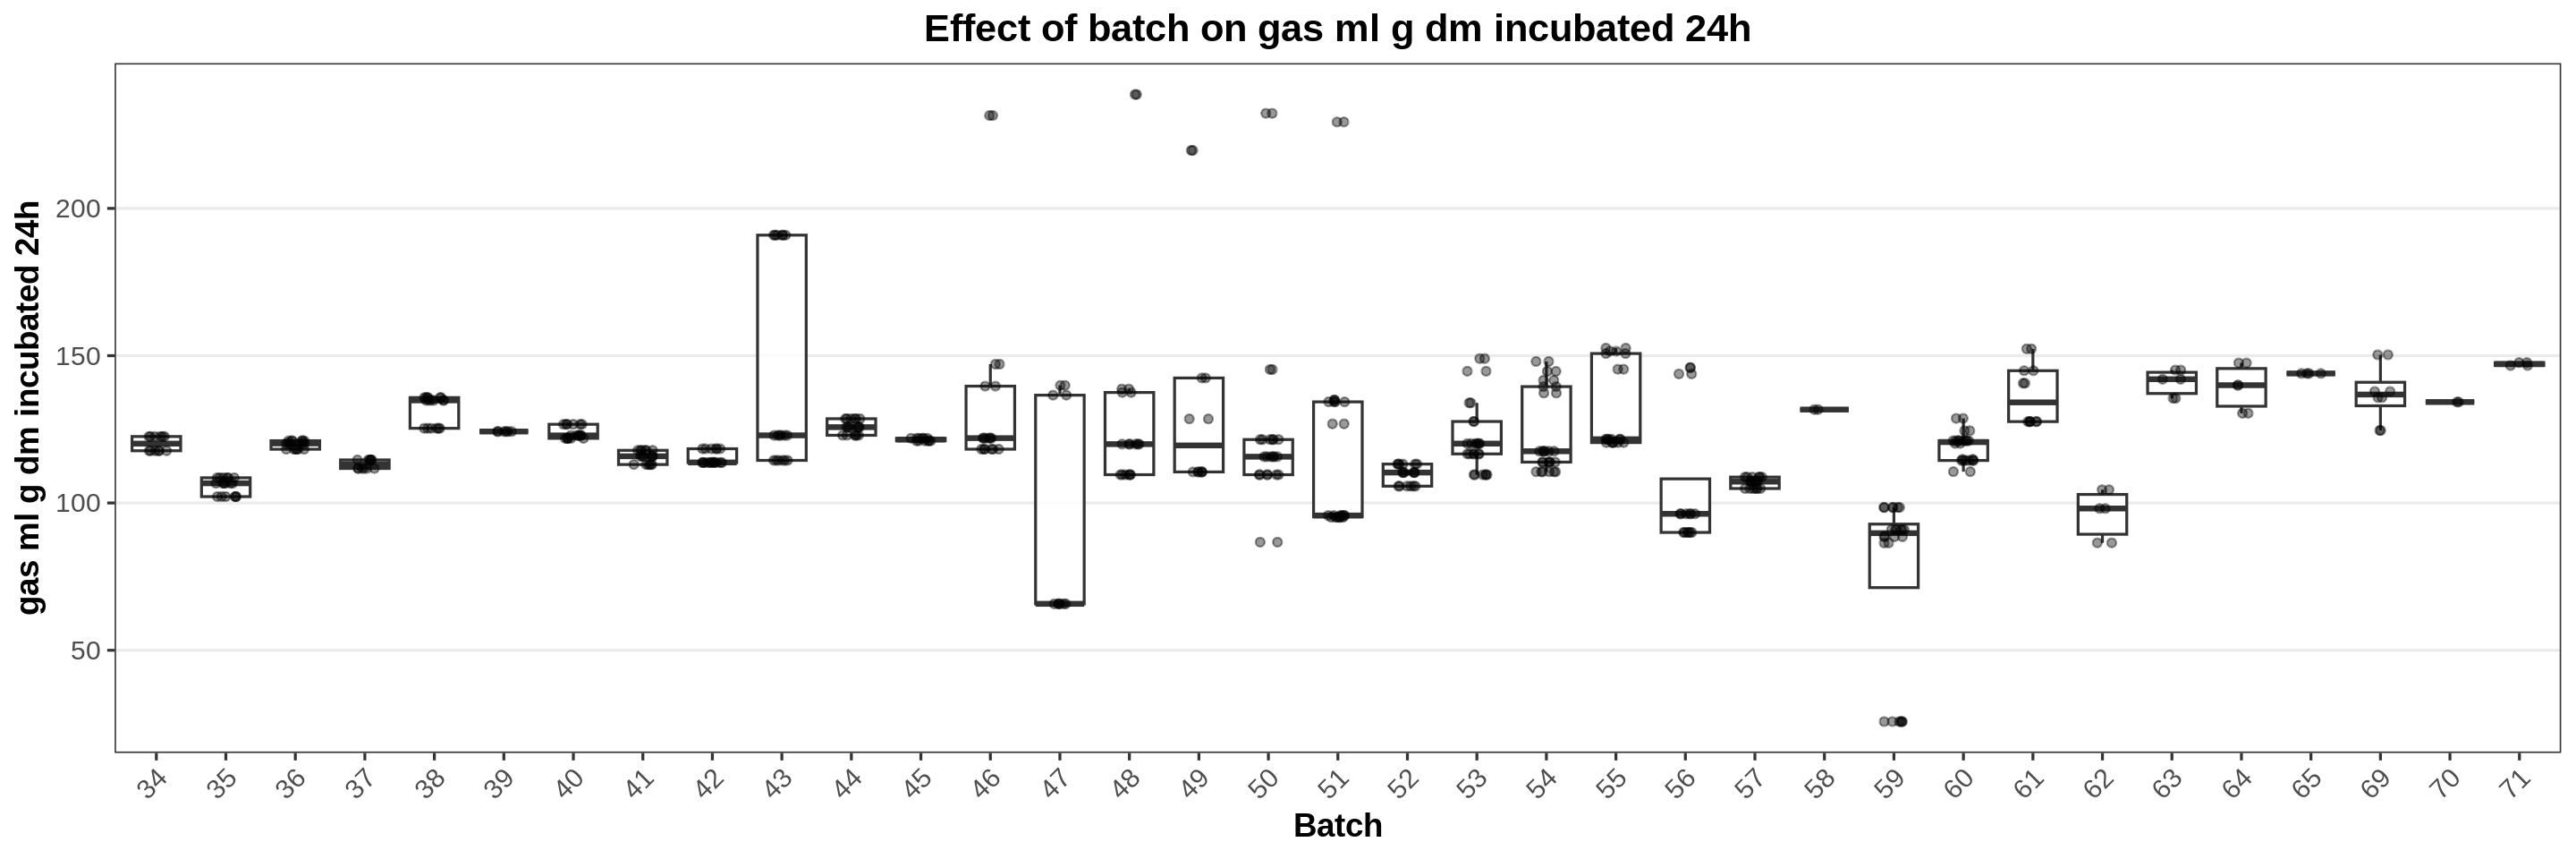

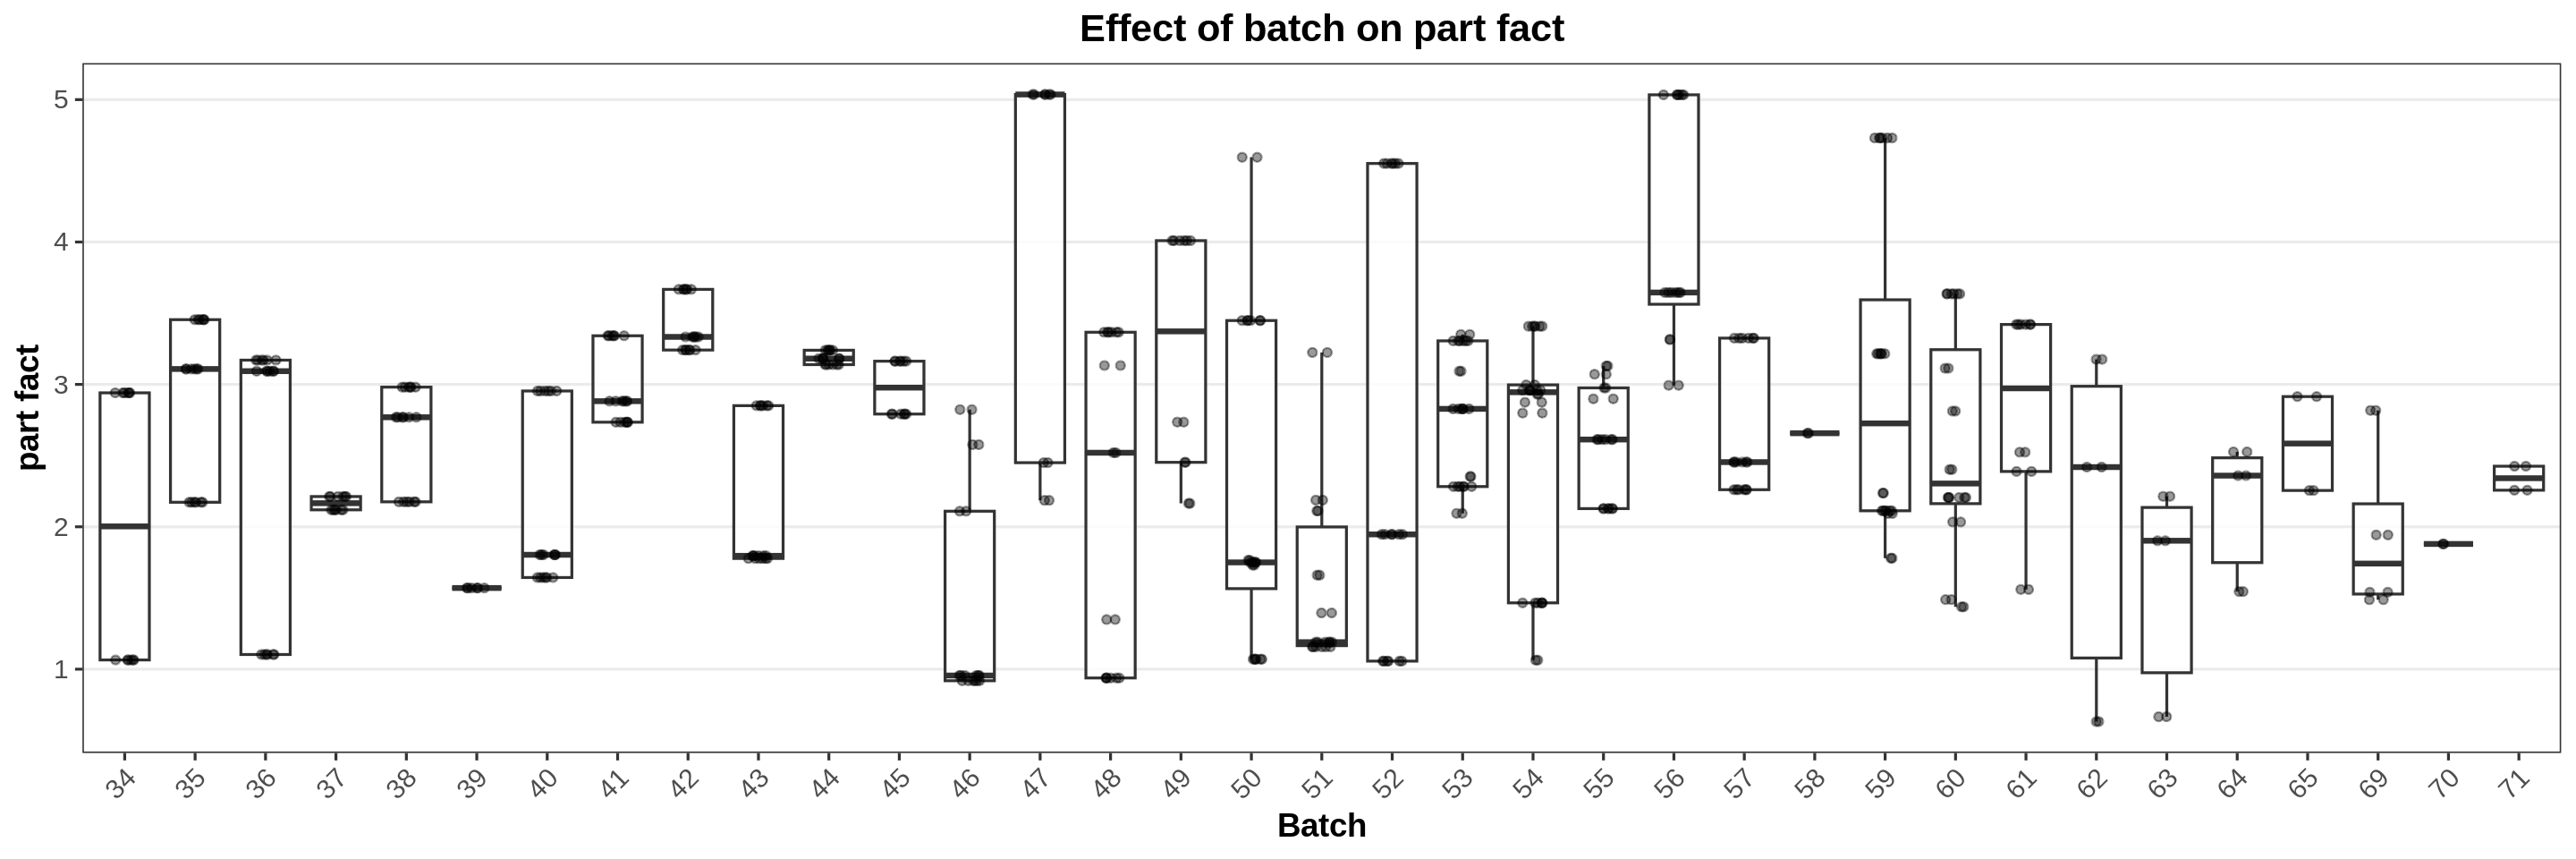

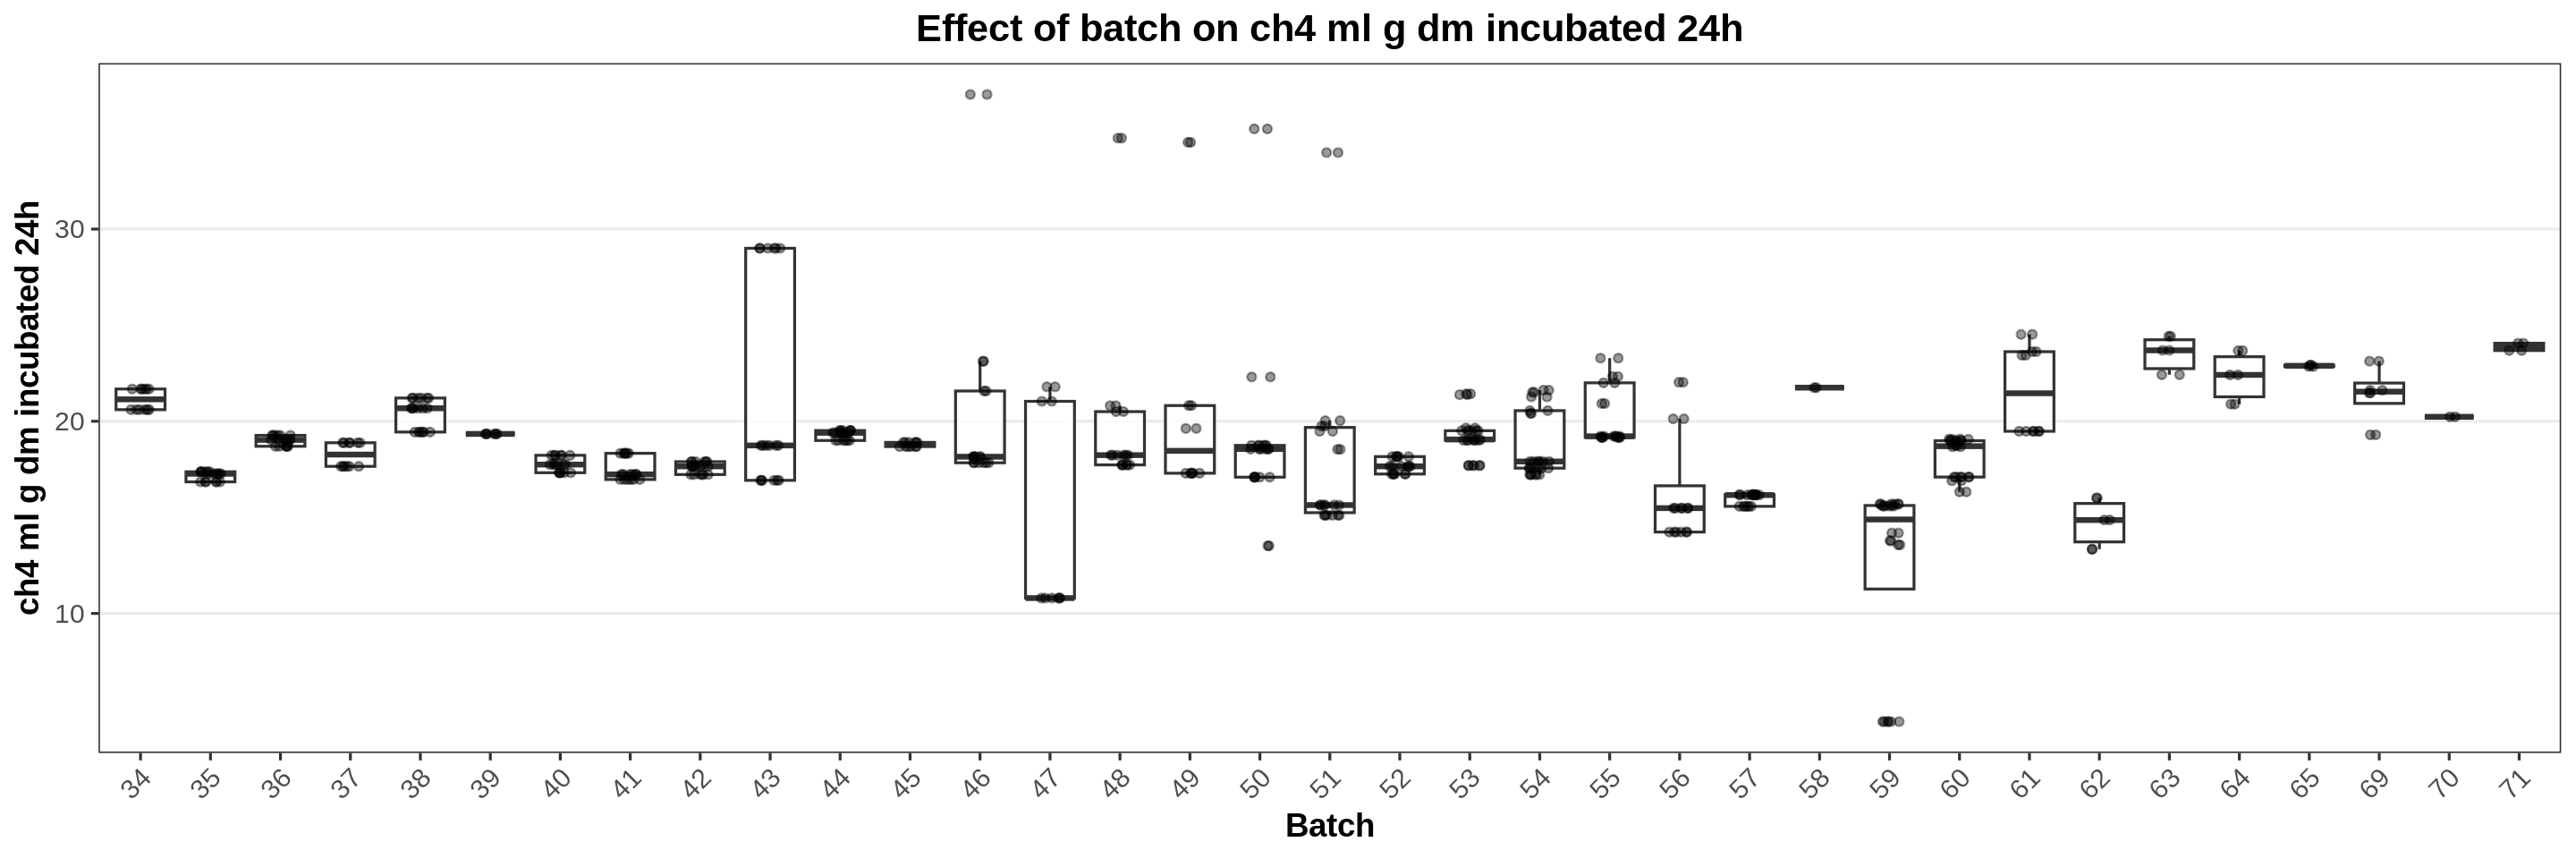

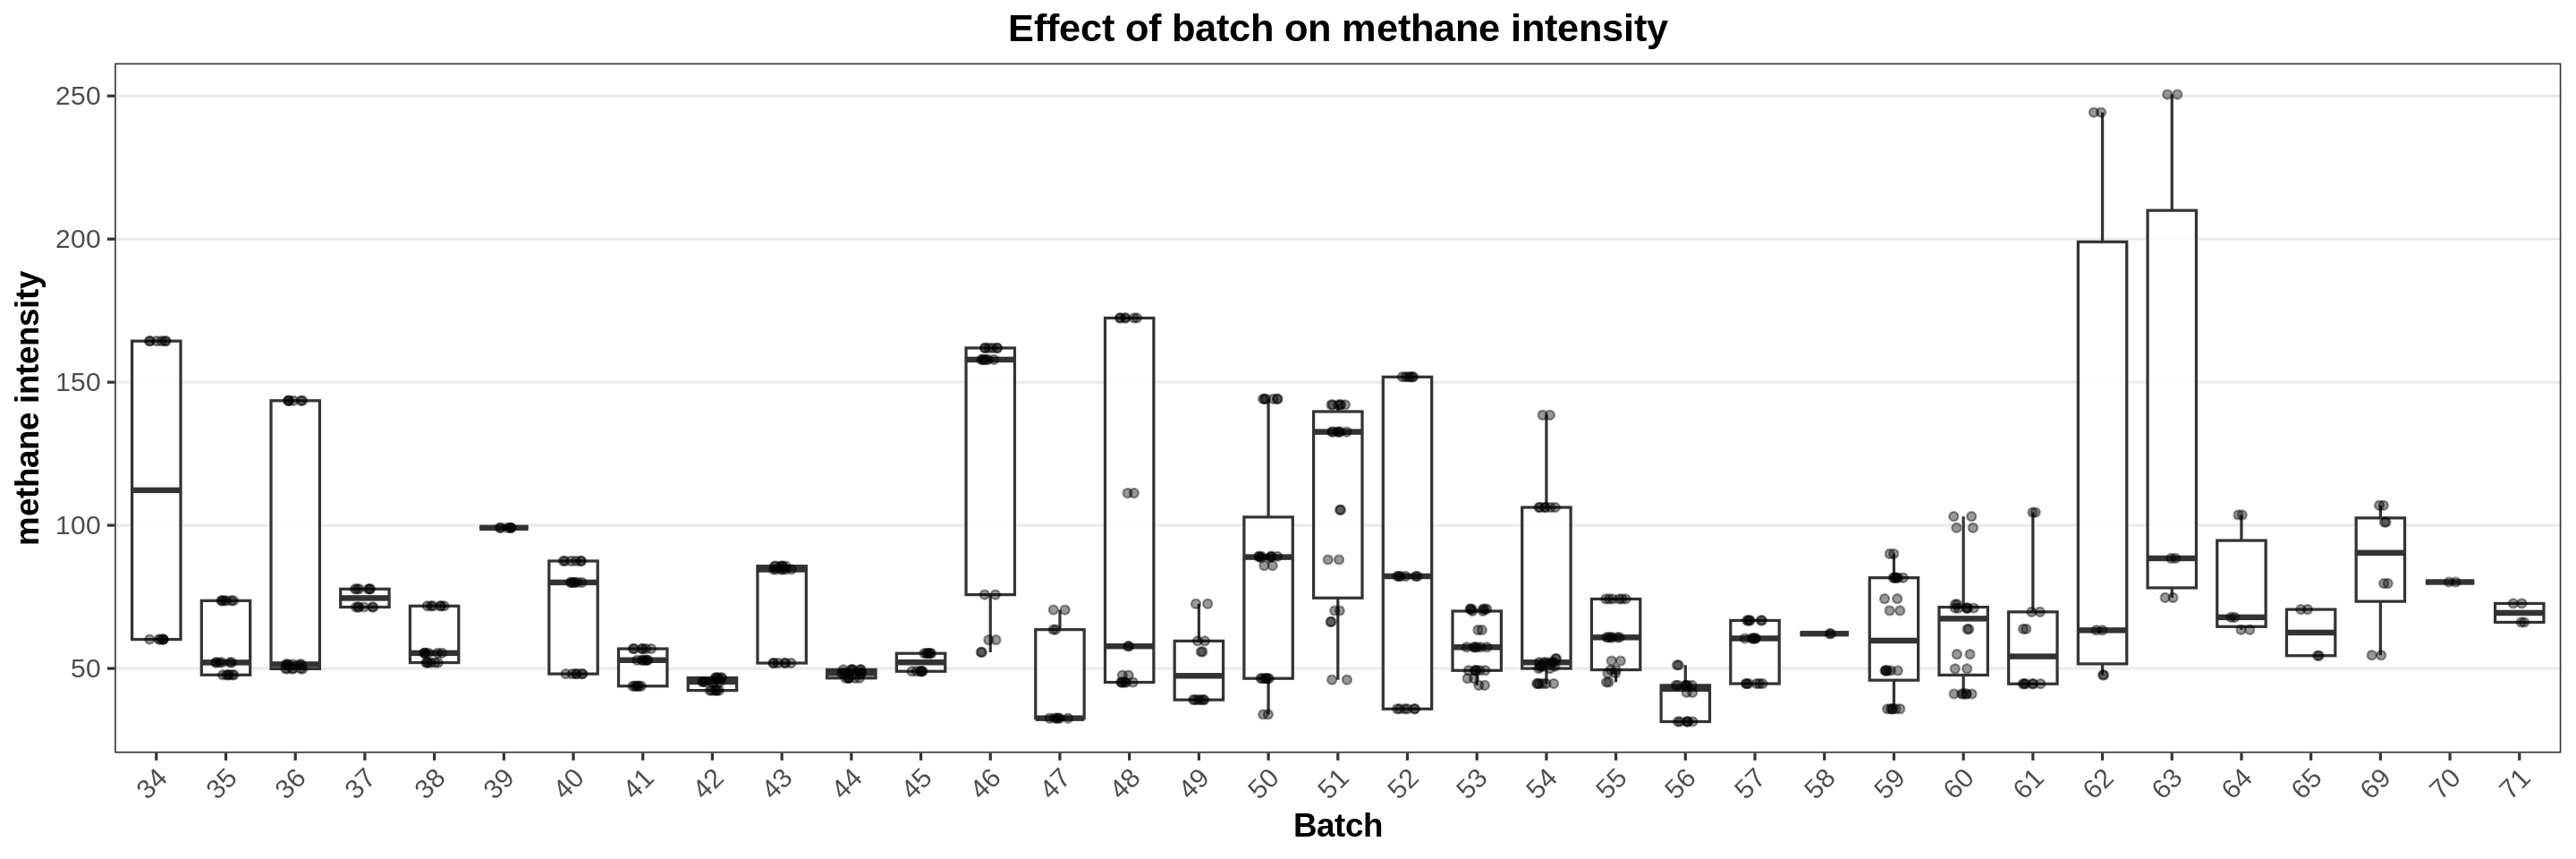

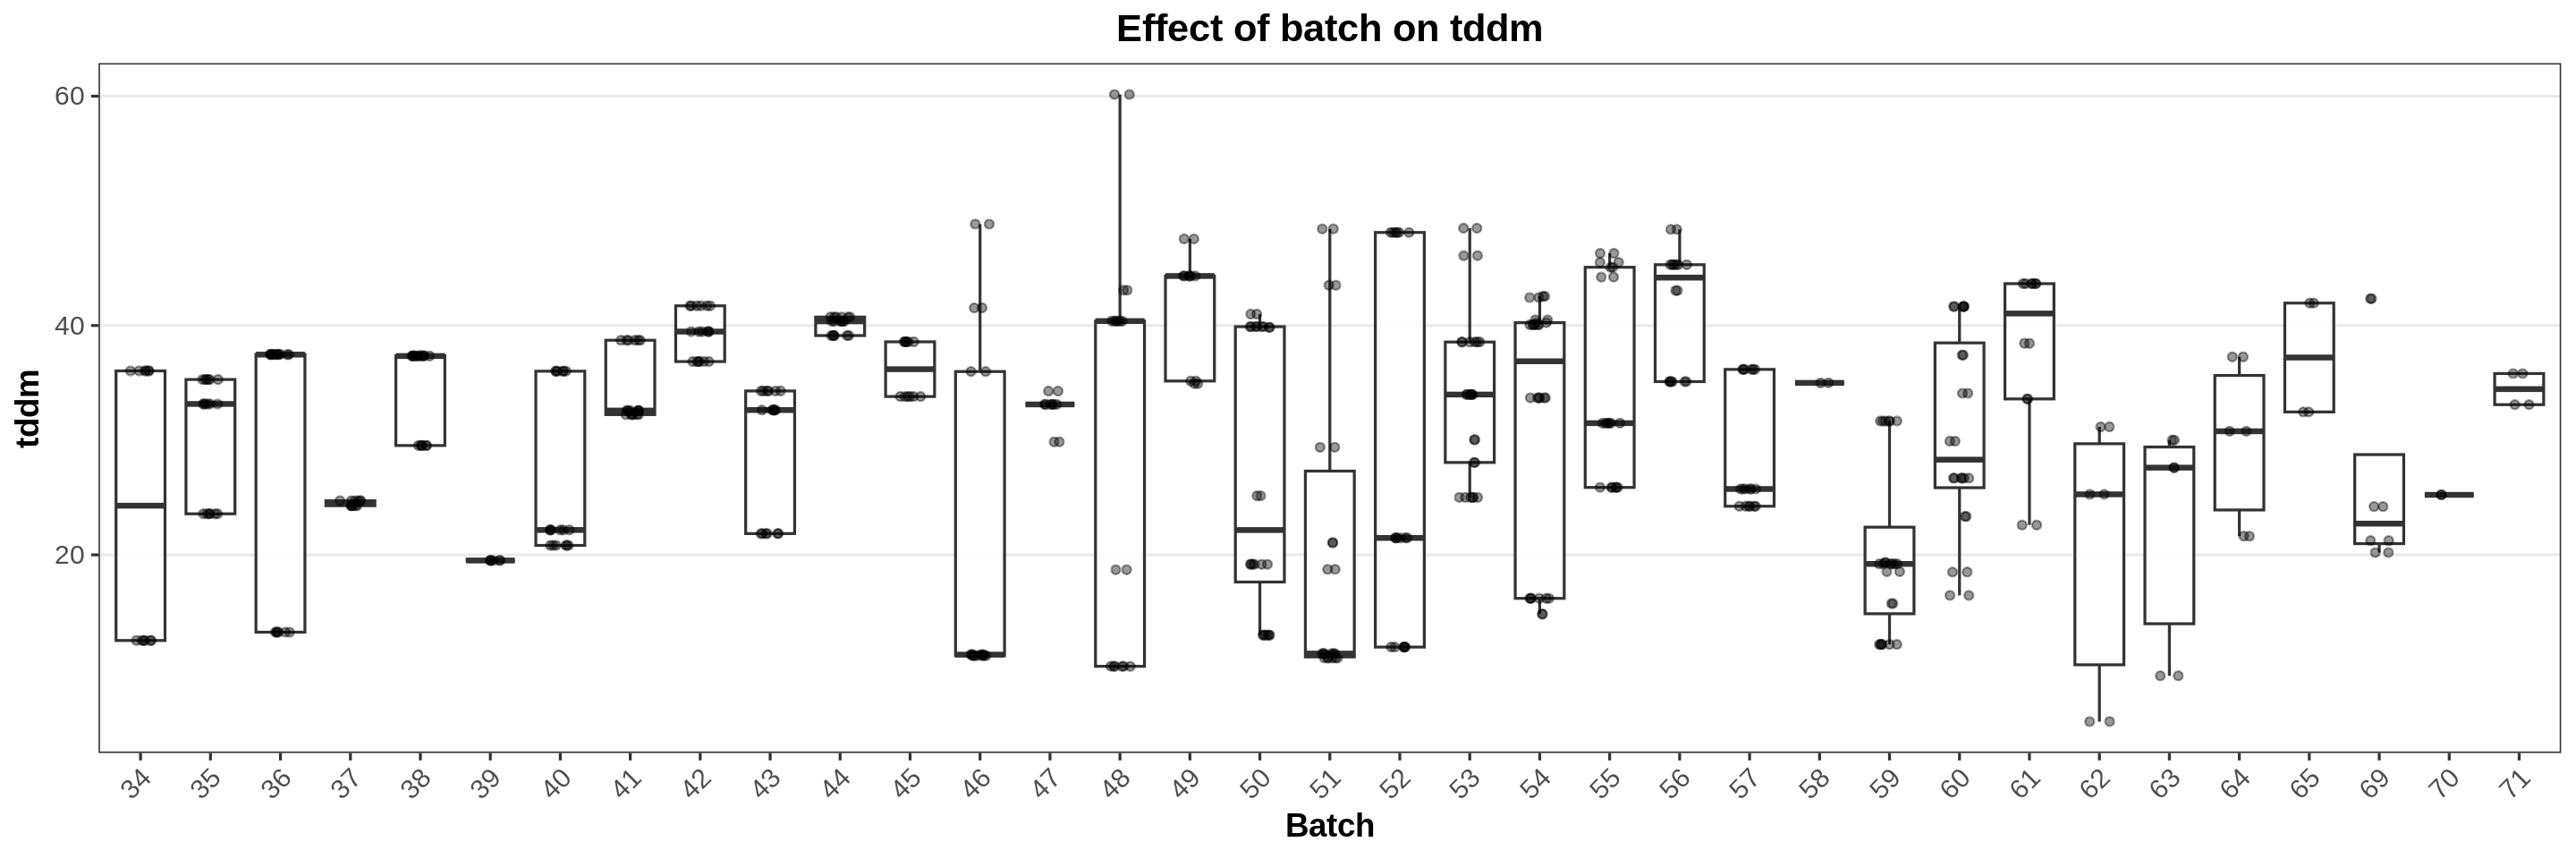

In [ ]:
# Boxplot for all quantitative variables
options(repr.plot.width = 24, repr.plot.height = 8)

for (v in variables) {
  print(plot_batch_boxplot(star_grass, v))
}

In [ ]:


plot_batch_boxplot <- function(data, variable) {

  #===========================
  # One-way ANOVA
  #===========================
  modelo <- lm(
    as.formula(paste(variable, "~ factor(batch)")),
    data = data
  )

  aov_tab <- anova(modelo)

  Fvalue <- round(aov_tab$`F value`[1], 2)
  pvalue <- aov_tab$`Pr(>F)`[1]

  p_label <- ifelse(
    pvalue < 0.001,
    "p < 0.001",
    paste0("p = ", signif(pvalue, 3))
  )

  #===========================
  # Plot
  #===========================
  ggplot(
    data,
    aes(
      x = factor(batch),
      y = .data[[variable]],
      fill = factor(batch)
    )
  ) +

    geom_boxplot(
      width = 0.70,
      alpha = 0.85,
      colour = "grey30",
      linewidth = 0.6,
      outlier.shape = NA
    ) +

    geom_jitter(
      width = 0.15,
      size = 2,
      alpha = 0.45,
      colour = "black"
    ) +

    # Soft pastel viridis colors
    scale_fill_viridis_d(
      option = "mako",
      begin = 0.20,
      end = 0.90
    ) +

    labs(
      x = "Batch",
      y = gsub("_", " ", variable),
      title = paste(
        "Effect of batch on",
        gsub("_", " ", variable)
      )
    ) +

    annotate(
      "text",
      x = Inf,
      y = Inf,
      hjust = 1.05,
      vjust = 1.4,
      size = 6,
      fontface = "bold",
      label = paste0(
        "ANOVA  ",
        "F = ", Fvalue,
        "\n",
        p_label
      )
    ) +

    theme_bw(base_size = 20) +

    theme(

      legend.position = "none",

      plot.title = element_text(
        size = 26,
        face = "bold",
        hjust = 0.5
      ),

      axis.title = element_text(
        size = 22,
        face = "bold"
      ),

      axis.text.x = element_text(
        size = 18,
        angle = 45,
        hjust = 1
      ),

      axis.text.y = element_text(
        size = 18
      ),

      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank()
    )

}

In [ ]:
# Boxplot for all quantitative variables
options(repr.plot.width = 24, repr.plot.height = 8)

for (v in variables) {
  print(plot_batch_boxplot(star_grass, v))
}

Output hidden; open in https://colab.research.google.com to view.

### 4.3 BLUEs estimation

### 4.3 BLUEs estimation

In [ ]:
install.packages(c("emmeans", "lmerTest"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#' Compute BLUEs, Variance Components, and Average LSD Using Mixed Models
#'
#' For each trait, fits a mixed model with accession as fixed effect and trial
#' as random effect. Extracts BLUEs (best linear unbiased estimates) via emmeans,
#' computes variance components from a random-effects-only model, and calculates
#' the average LSD for pairwise comparisons.
#'
#' @param raw_data data.frame. The uploaded raw data with multiple observations
#'   per accession across trials.
#' @param trait_cols Character vector. Names of numerical trait columns.
#' @param accession_col Character. Name of the accession ID column.
#' @param trial_col Character. Name of the trial/run ID column.
#' @return A named list with:
#'   - blues: data.frame with one row per accession, columns for each trait BLUE
#'   - variance_components: data.frame with variance sources per trait
#'   - avg_lsd: named numeric vector of average LSD per trait
#'   - errors: character vector of traits that failed model fitting
compute_blues <- function(raw_data, trait_cols, accession_col, trial_col) {
  # Ensure factors
  raw_data[[accession_col]] <- factor(raw_data[[accession_col]])
  raw_data[[trial_col]] <- factor(raw_data[[trial_col]])

  blues_list <- list()
  variance_list <- list()
  lsd_values <- c()
  errors <- character(0)

  for (trait in trait_cols) {
    tryCatch({
      # Skip if trait has too few non-NA values
      non_na_count <- sum(!is.na(raw_data[[trait]]))
      if (non_na_count < 5) {
        errors <- c(errors, paste0(trait, " (insufficient data)"))
        next
      }

      # Model 1: random-effects only for variance components
      formula_vc <- as.formula(paste0("`", trait, "` ~ (1 | `", accession_col, "`) + (1 | `", trial_col, "`)"))
      model_vc <- lme4::lmer(formula_vc, data = raw_data, REML = TRUE)

      vc <- as.data.frame(lme4::VarCorr(model_vc))
      total_var <- sum(vc$vcov)
      vc_df <- data.frame(
        Trait = trait,
        Source = vc$grp,
        Variance = round(vc$vcov, 4),
        Pct_of_Total = round(100 * vc$vcov / total_var, 2),
        stringsAsFactors = FALSE
      )
      variance_list[[trait]] <- vc_df

      # Model 2: accession fixed, trial random for BLUEs
      formula_blue <- as.formula(paste0("`", trait, "` ~ `", accession_col, "` + (1 | `", trial_col, "`)"))
      model_blue <- lme4::lmer(formula_blue, data = raw_data, REML = TRUE)

      # Extract BLUEs via emmeans
      blues_emm <- emmeans::emmeans(model_blue, as.formula(paste0("~ `", accession_col, "`")), lmer.df = "asymptotic")
      blues_df <- as.data.frame(summary(blues_emm))

      # Compute average LSD
      vcov_mat <- vcov(blues_emm)
      pairwise_se <- sqrt(outer(diag(vcov_mat), diag(vcov_mat), "+") - 2 * as.matrix(vcov_mat))
      pairwise_se_vals <- pairwise_se[upper.tri(pairwise_se)]
      df_val <- summary(blues_emm)$df[1]
      avg_lsd <- signif(mean(qt(0.975, df = df_val) * pairwise_se_vals, na.rm = TRUE), 4)
      lsd_values[trait] <- avg_lsd

      # Store BLUEs
      blue_result <- data.frame(
        accession = blues_df[[accession_col]],
        value = blues_df$emmean,
        se = blues_df$SE,
        stringsAsFactors = FALSE
      )
      names(blue_result) <- c(accession_col, trait, paste0(trait, "_SE"))
      blues_list[[trait]] <- blue_result

    }, error = function(e) {
      errors <<- c(errors, paste0(trait, " (", e$message, ")"))
    })
  }

  # Merge all BLUE estimates into one data.frame
  if (length(blues_list) > 0) {
    blues_merged <- Reduce(function(x, y) merge(x, y, by = accession_col, all = TRUE), blues_list)
  } else {
    blues_merged <- data.frame()
  }

  # Combine variance components
  variance_df <- if (length(variance_list) > 0) dplyr::bind_rows(variance_list) else data.frame()

  list(
    blues = blues_merged,
    variance_components = variance_df,
    avg_lsd = lsd_values,
    errors = errors
  )
}


In [ ]:
names(gas_raw)

[1] "subset"                    "no"                       
 [3] "requisitioner"             "id_lab"                   
 [5] "id"                        "tax_order"                
 [7] "family"                    "genus"                    
 [9] "species"                   "tax_name"                 
[11] "functional_group"          "set_ciat"                 
[13] "batch"                     "run"                      
[15] "replication"               "syrange"                  
[17] "sample_weight_g"           "undigested_dm_g"          
[19] "dm_incubated"              "digested_feed_mg"         
[21] "net_gas_8h_ml"             "net_gas_24h_ml"           
[23] "ch4_8h_ml"                 "ch4_24h_ml"               
[25] "ch4_percentage_in_gas_8h"  "ch4_percentage_in_gas_24h"
[27] "gas_ml_g_dm_incubated_24h" "part_fact"                
[29] "ch4_ml_g_dm_incubated_24h" "ch4_ml_g_ndf_digested_24h"
[31] "methane_intensity"         "tddm"                     
[33] "information_remarks_1"     "information_remarks_2"    
[35] "gas_remarks_1"             "gas_remarks_2"            
[37] "digest_remarks_1"          "digest_remarks_2"         
[39] "delete"

In [26]:
results <- compute_blues(
  raw_data = gas_raw,
  trait_cols = variables,
  accession_col = "id_lab",
  trial_col = "batch"
)

In [27]:
res$blues

ERROR: Error: object 'res' not found


# Mixed model

## Batch as random effect

In [ ]:
library(lme4)

In [ ]:
modelo <- lmer(methane_intensity ~ id_lab + (1|batch),
               data=gas_raw)

In [ ]:
#summary(modelo)

In [ ]:
VarCorr(modelo)

In [ ]:
vc <- as.data.frame(VarCorr(modelo))
vc

In [ ]:
batch.var <- vc$vcov[1]
res.var   <- vc$vcov[2]

In [ ]:
batch.var/(batch.var + res.var)

In [ ]:
gas_raw$adjusted <- predict(modelo)


In [ ]:
gas_raw$adjusted

## Genotype and batch as random effect to know variance components

In [ ]:
gas_raw